# Testing Architecture on multiple cities

The previous notebooks relied on creating different models, understanding them and studying how they learned through the study of attention.
Now we will try to explore the performances of models that combined both the message passing and the attention mechanism.
We will use the same dataset as before, but we will try to train the model on multiple cities at once.


## Preprocessing part

In [1]:
import torch    
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from collections import Counter
from torch_geometric.data import InMemoryDataset, Data
import torch_geometric
from torch_geometric.nn import GATv2Conv
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn import GATConv
import pytest


In [2]:
# load the data
city_list = ['PC','CR','PU','TR','RI']
node_columns = ['osmid', 'y', 'x', 'street_count', 'bc', 'traffic_lights', 'geometry']
nodes = {}
edges = {}

for city in city_list:
    nodes[city] = gpd.read_file(f'cities/nodes_{city}.geojson')
    edges[city] = gpd.read_file(f'cities/edges_{city}.geojson')

    # Filter columns (should be in the same loop)
    nodes[city] = nodes[city][[col for col in nodes[city].columns if col in node_columns]]

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5
Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5
Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5
Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field wid

In [3]:
nodes["CR"].head()

,osmid,y,x,street_count,bc,traffic_lights,geometry
0,249617125,5.000033e+06,578681.931488,3,0.221561,False,POINT (578681.931 5000032.907)
1,302402633,4.999980e+06,578679.421611,3,0.221585,False,POINT (578679.422 4999980.367)
2,249617128,4.999968e+06,578742.690104,3,0.231506,False,POINT (578742.69 4999967.629)
3,302402587,4.999994e+06,578765.527141,3,0.246801,False,POINT (578765.527 4999993.867)
4,302415503,4.999956e+06,578784.130629,3,0.288959,False,POINT (578784.131 4999955.721)


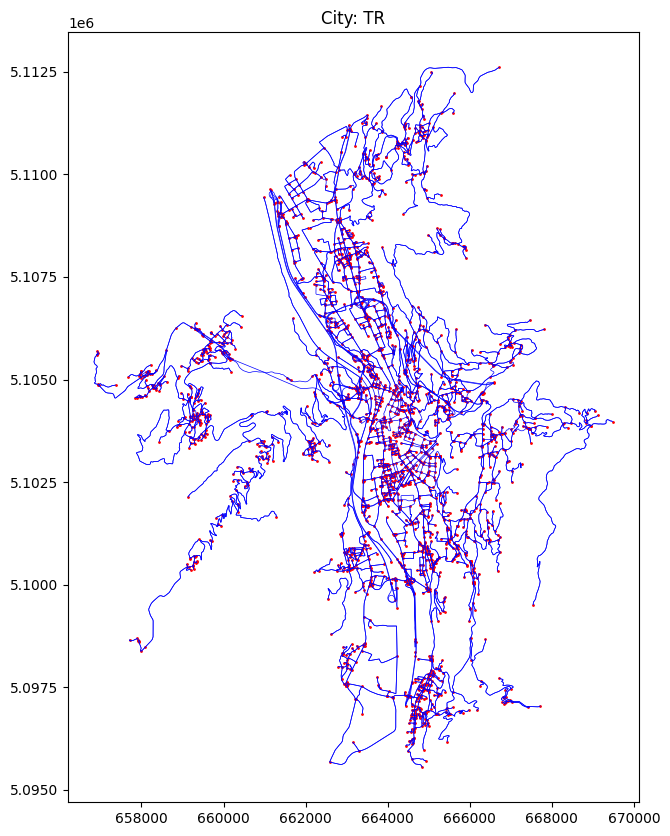

In [4]:
def plot_city(city):
    fig, ax = plt.subplots(figsize=(10, 10))
    nodes[city].plot(ax=ax, color='red', markersize=1)
    edges[city].plot(ax=ax, color='blue', linewidth=0.5)
    plt.title(f'City: {city}')
    plt.show()

# Plot a city
plot_city('TR')

Preparing the data

In [5]:
# Preprocess the data and prepare the dataset
def preprocess_data(nodes, edges):
    scaler = StandardScaler()
    # X only needs to drop geometry
    X = nodes.drop(columns=['geometry', 'osmid']).values
    X = np.array(X)
    X = scaler.fit_transform(X)
    
    # Y is the traffic speed
    Y = edges['traffic_speed'].values
    Y = np.array(Y)

    # Edge index
    # Prepare edge index 
    node_to_id = {}
    for i, node in enumerate(nodes['osmid'].values):
        node_to_id[node] = i

    start_node = [node_to_id[i] for i in edges['u'].values]
    end_node = [node_to_id[i] for i in edges['v'].values]
    start = torch.tensor(start_node, dtype=torch.long)
    end = torch.tensor(end_node, dtype=torch.long)
    edge_index = torch.stack([start, end], dim=0)

    transform = T.AddRandomWalkPE( walk_length= 20, attr_name= 'pe')
    data = Data(x = torch.FloatTensor(X), y = torch.FloatTensor(Y), edge_index = edge_index )
    data = transform(data)


    np.random.seed(0)
        
    n_edges = data.num_edges
    indices = np.random.permutation(n_edges)
            
    train_idx = indices[:int(0.7 * n_edges)]
    #print(len(train_idx)) #debug
    val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
    #print(len(val_idx)) #debug
    test_idx = indices[int(0.85 * n_edges):]
    #print(len(test_idx)) #debug
            
    # Create masks
    train_mask = torch.zeros(n_edges, dtype=torch.bool)
    val_mask = torch.zeros(n_edges, dtype=torch.bool)
    test_mask = torch.zeros(n_edges, dtype=torch.bool)
        
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
            
    data.train_mask = train_mask    #size is still all nodes but only True for train nodes
    data.val_mask = val_mask
    data.test_mask = test_mask
        
    return data
data = preprocess_data(nodes['TR'], edges['TR'])
print(data)

/opt/anaconda3/envs/urbanity/lib/python3.9/site-packages/torch_geometric/transforms/add_positional_encoding.py:169: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:55.)
  out = out @ adj


Data(x=[2904, 5], edge_index=[2, 6151], y=[6151], pe=[2904, 20], train_mask=[6151], val_mask=[6151], test_mask=[6151])


In [6]:
#check the target
max(data.y - np.array(edges['TR']['traffic_speed'].values))

tensor(5.7220e-06, dtype=torch.float64)

Everything works so it's time to create the real dataset and data loader

In [7]:
# Preprocess all the cities
processed_data = {}
for city in city_list:
    print(f"Processing city: {city}")
    processed_data[city] = preprocess_data(nodes[city], edges[city])
    print(f"Processed {city} with {processed_data[city].num_nodes} nodes and {processed_data[city].num_edges} edges.")
# Verify all cities were processed
print("\nProcessed cities:")
for city, data in processed_data.items():
    print(f"- {city}: {data.num_nodes} nodes, {data.num_edges} edges")

Processing city: PC
Processed PC with 3231 nodes and 6930 edges.
Processing city: CR
Processed CR with 2280 nodes and 4786 edges.
Processing city: PU
Processed PU with 3849 nodes and 8164 edges.
Processing city: TR
Processed TR with 2904 nodes and 6151 edges.
Processing city: RI
Processed RI with 6008 nodes and 12464 edges.

Processed cities:
- PC: 3231 nodes, 6930 edges
- CR: 2280 nodes, 4786 edges
- PU: 3849 nodes, 8164 edges
- TR: 2904 nodes, 6151 edges
- RI: 6008 nodes, 12464 edges


In [8]:
# Data Loader
from torch_geometric.loader import DataLoader

data_list = list(processed_data.values())
loader = DataLoader(data_list, batch_size=1, shuffle=True)
for batch in loader:
    print(f"Batch with {batch.num_nodes} nodes and {batch.num_edges} edges")

Batch with 2904 nodes and 6151 edges
Batch with 3849 nodes and 8164 edges
Batch with 3231 nodes and 6930 edges
Batch with 6008 nodes and 12464 edges
Batch with 2280 nodes and 4786 edges


## First model is not quite like GPS:
It combines Performer and GNN but only at the end of the embedding process.

In [ ]:
class HybridModel(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_transformer_layers: int = 2,
        num_gat_layers: int = 2,
        dropout: float = 0.4,
        combine_method: str = 'concat',  # 'concat', 'sum'
    ):
        super().__init__()
        
        # Input embeddings
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # Transformer branch (DeepGraphPerformer)
        self.transformer_layers = nn.ModuleList()
        for _ in range(num_transformer_layers):
            layer = nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_channels),
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                'norm2': nn.LayerNorm(hidden_channels),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.transformer_layers.append(layer)
        
        # GAT branch - with varying head configurations
        self.gat_layers = nn.ModuleList()
        self.gat_norms = nn.ModuleList()
        self.gat_ffns = nn.ModuleList()
        
        for i in range(num_gat_layers):
            # Layer-specific head configuration (last layer has single head)
            layer_heads = heads if i < num_gat_layers - 1 else 1
            
            # Pre-normalization
            self.gat_norms.append(nn.LayerNorm(hidden_channels))
            
            # GAT layer
            self.gat_layers.append(
                GATConv(hidden_channels, hidden_channels // layer_heads, 
                        heads=layer_heads, concat=True, dropout=dropout)
            )
            
            # Feed-forward network after each GAT layer
            self.gat_ffns.append(nn.Sequential(
                nn.LayerNorm(hidden_channels),  # Normalize before FFN
                nn.Linear(hidden_channels, hidden_channels*2),
                nn.Dropout(dropout),
                nn.ReLU(),
                nn.Linear(hidden_channels*2, hidden_channels)
            ))
        
        # Final layer normalization
        self.transformer_norm = nn.LayerNorm(hidden_channels)
        self.gat_norm = nn.LayerNorm(hidden_channels)
        
        # Combination method
        self.combine_method = combine_method
        if combine_method == 'concat':
            self.combine = nn.Sequential(
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.ReLU()
            )
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index, batch=None):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Transformer branch
        transformer_x = x
        for layer in self.transformer_layers:
            # Pre-normalization for attention
            residual = transformer_x
            transformer_x_norm = layer['norm1'](transformer_x)
            
            # Apply attention with residual
            transformer_x_attn = transformer_x_norm.unsqueeze(0)
            transformer_x_attn = layer['attention'](transformer_x_attn)
            transformer_x = residual + transformer_x_attn.squeeze(0)
            
            # Pre-normalization for FFN
            residual = transformer_x
            transformer_x = layer['norm2'](transformer_x)
            
            # Apply FFN with residual
            transformer_x = residual + layer['ffn'](transformer_x)
        
        # Final transformer normalization
        transformer_x = self.transformer_norm(transformer_x)
        
        # GAT branch with proper residual connections
        gat_x = x
        for i, (norm, gat_layer, ffn) in enumerate(zip(self.gat_norms, self.gat_layers, self.gat_ffns)):
            # Pre-normalization
            residual = gat_x
            gat_x_norm = norm(gat_x)
            
            # Apply GAT with residual
            gat_conv = gat_layer(gat_x_norm, edge_index)
            gat_x = residual + gat_conv
            
            # Apply FFN with residual
            residual = gat_x
            gat_x = residual + ffn(gat_x)
        
        # Final GAT normalization
        gat_x = self.gat_norm(gat_x)
        
        # Combine the normalized transformer and GAT embeddings
        if self.combine_method == 'sum':
            combined_x = transformer_x + gat_x
        elif self.combine_method == 'concat':
            combined_x = self.combine(torch.cat([transformer_x, gat_x], dim=1))
        
        # Edge prediction
        src, dst = edge_index
        edge_features = torch.cat([combined_x[src], combined_x[dst]], dim=1)
        edge_pred = self.output_layer(edge_features)
        
        return edge_pred
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.transformer_layers:
            attention = layer['attention']
            attention.redraw_projection_matrix()

In [60]:
device = 'cpu'
model = HybridModel(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

HybridModel(
  (node_emb): Linear(in_features=5, out_features=48, bias=True)
  (pe_lin): Linear(in_features=20, out_features=16, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Dropout(p=0.4, inplace=False)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (gat_layers): ModuleList(
    (0-1): 2 x GATConv(64, 16, heads=4)
  )
  (gat_norms): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (gat_ffns): ModuleList(
    (0-1): 2 x Sequential(
      (0): Linear(in_features

In [62]:
# Train and evaluate the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
def train(model, data):
    model.train()
    optimizer.zero_grad()
    if epoch < 5:
        redraw_freq = 1
    elif epoch < 150:
        redraw_freq = 30
    else:
        redraw_freq = 1111
    
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()

In [63]:
# Train loop
EPOCHS = 1000
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Reset epoch losses
    epoch_train_loss = 0
    epoch_val_loss = 0
    num_batches = 0
    
    # Process all batches in an epoch
    for batch in loader:
        batch = batch.to(device)
        train_loss = train(model, batch)
        val_loss = test(model, batch, batch.val_mask)
        
        # Accumulate batch losses
        epoch_train_loss += train_loss
        epoch_val_loss += val_loss
        num_batches += 1
    
    # Calculate average losses for the epoch
    epoch_train_loss /= num_batches
    epoch_val_loss /= num_batches
    
    # Record epoch losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Scheduler step with average validation loss
    scheduler.step(epoch_val_loss)
    
    # Early stopping based on epoch validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_models/best_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 10: Train Loss: 118.9597, Val Loss: 84.7345
Epoch 20: Train Loss: 100.1268, Val Loss: 68.1289
Epoch 30: Train Loss: 98.1304, Val Loss: 66.7097
Epoch 40: Train Loss: 94.6127, Val Loss: 63.8300
Epoch 50: Train Loss: 87.0129, Val Loss: 56.6084
Epoch 60: Train Loss: 90.9255, Val Loss: 58.7226
Epoch 70: Train Loss: 84.7598, Val Loss: 54.1709
Epoch 80: Train Loss: 81.9006, Val Loss: 52.8834
Epoch 90: Train Loss: 90.5651, Val Loss: 57.8872
Epoch 100: Train Loss: 80.1435, Val Loss: 50.9792
Epoch 110: Train Loss: 79.4198, Val Loss: 51.1351
Epoch 120: Train Loss: 85.9447, Val Loss: 54.4702
Epoch 130: Train Loss: 77.3118, Val Loss: 49.5831
Epoch 140: Train Loss: 75.1097, Val Loss: 49.2982
Epoch 150: Train Loss: 74.7262, Val Loss: 47.9671
Epoch 160: Train Loss: 75.2614, Val Loss: 48.4482
Epoch 170: Train Loss: 74.3571, Val Loss: 46.9367
Epoch 180: Train Loss: 72.1828, Val Loss: 46.5442
Epoch 190: Train Loss: 72.8704, Val Loss: 46.7590
Epoch 200: Train Loss: 70.0956, Val Loss: 44.8755
Epoch 2

In [64]:
# load the best model
model = HybridModel(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.load_state_dict(torch.load('best_models/best_model.pth'))
model.to(device)

# Evaluate the model on the test set per city
test_losses = {}
for city, data in processed_data.items():
    data = data.to(device)
    test_loss = test(model, data, data.test_mask)
    test_losses[city] = test_loss
    print(f"Test Loss for {city}: {test_loss:.4f}")

Test Loss for PC: 42.5250
Test Loss for CR: 25.2384
Test Loss for PU: 38.4906
Test Loss for TR: 39.0951
Test Loss for RI: 31.7707


In [65]:
#plot the predictions per city
def plot_predictions(city, model, data, edges):
    edges = edges[city]
    data = data[city].to(device)
    model.eval()
    with torch.no_grad():        
        pred = model(data.x, data.pe, data.edge_index).squeeze(-1)
        edges['predicted_speed'] = pred.cpu().numpy()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        edges.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis')
        ax1.set_axis_off()
        ax1.set_title('True Traffic Speed')
        edges.plot(column='predicted_speed', ax=ax2, legend=True, cmap='viridis')
        ax2.set_axis_off()
        ax2.set_title('Predicted Traffic Speed')
        plt.suptitle(f'City: {city}')
        plt.tight_layout()
        plt.show()
        

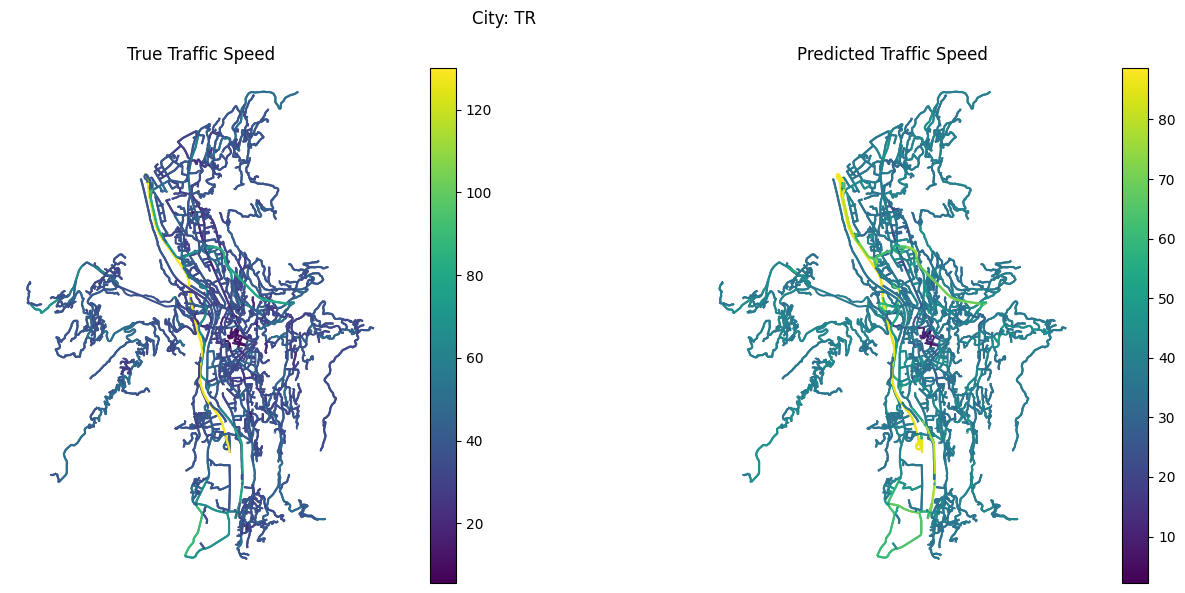

In [66]:
plot_predictions('TR', model, processed_data, edges)

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


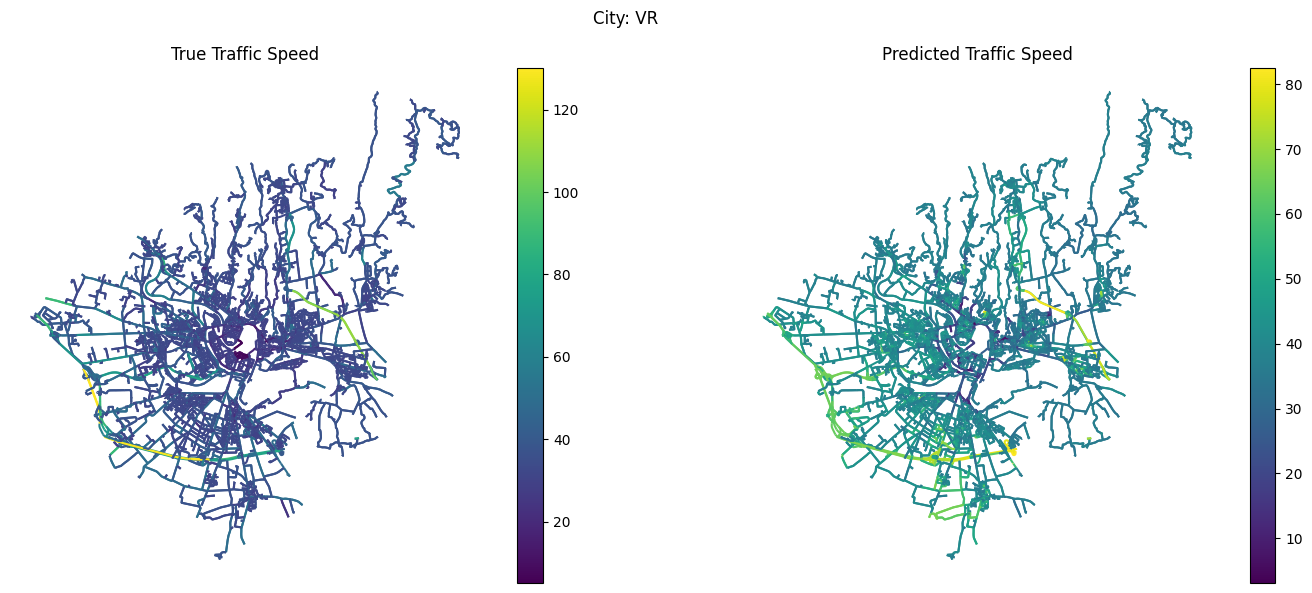

Test Loss for VR: 102.5281


In [67]:
#import a new city to test
nodes_vr = gpd.read_file(f'cities/nodes_VR.geojson')
edges_vr = gpd.read_file(f'cities/edges_VR.geojson')

nodes_vr = nodes_vr[[col for col in nodes_vr.columns if col in node_columns]]

vr_data = preprocess_data(nodes_vr, edges_vr)
plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})
# compute loss
loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {loss:.4f}")

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


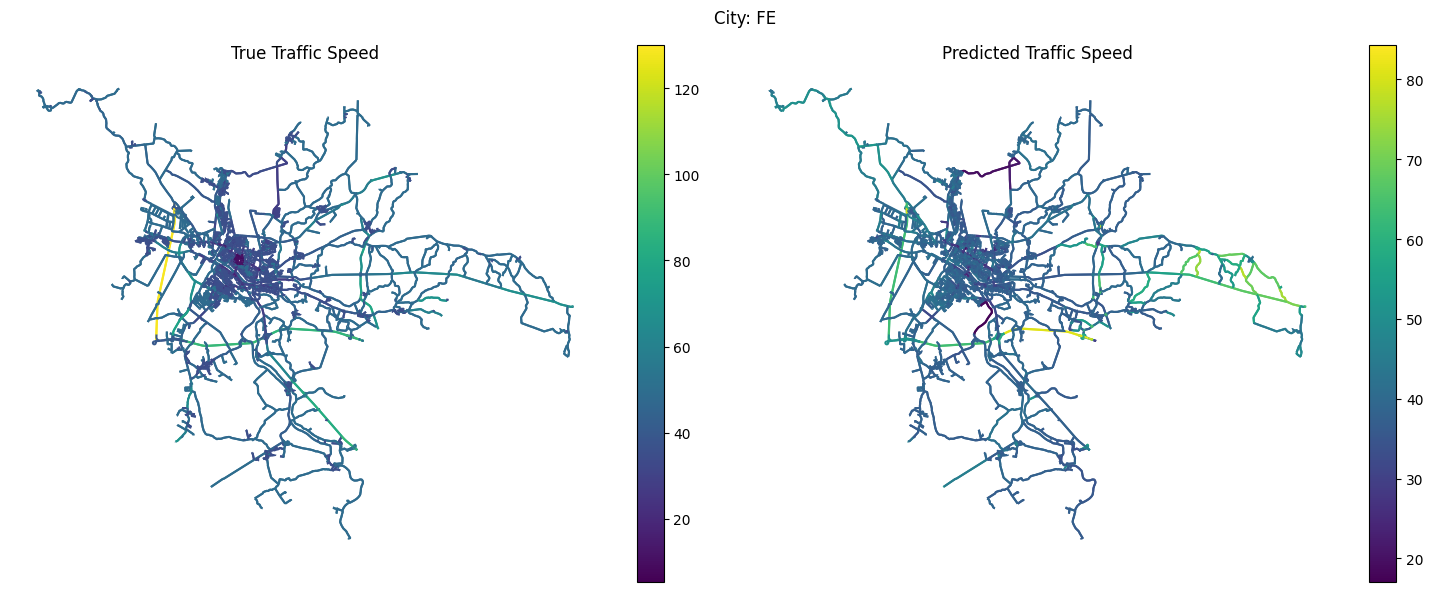

Test Loss for FE: 74.3325


In [68]:
#import a new city to test
nodes_fe = gpd.read_file(f'cities/nodes_FE.geojson')
edges_fe = gpd.read_file(f'cities/edges_FE.geojson')

nodes_fe = nodes_fe[[col for col in nodes_fe.columns if col in node_columns]]

fe_data = preprocess_data(nodes_fe, edges_fe)
plot_predictions('FE', model, {'FE': fe_data}, {'FE': edges_fe})
# compute loss
loss = test(model, fe_data, fe_data.test_mask)
print(f"Test Loss for FE: {loss:.4f}")

## 1.5 model is the same as the first one but with the GNN part that also receives the positional encoding.

In [ ]:
class HybridModel_variant(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_transformer_layers: int = 2,
        num_gat_layers: int = 2,
        dropout: float = 0.4,
        combine_method: str = 'concat',  # 'concat', 'sum'
    ):
        super().__init__()
        
        # Shared input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # Transformer branch (DeepGraphPerformer)
        self.transformer_layers = nn.ModuleList()
        for _ in range(num_transformer_layers):
            layer = nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_channels),
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                'norm2': nn.LayerNorm(hidden_channels),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.transformer_layers.append(layer)
        
        # GAT branch
        self.gat_layers = nn.ModuleList()
        self.gat_norms = nn.ModuleList()
        self.gat_ffns = nn.ModuleList()
        
        for i in range(num_gat_layers):
            # GAT layer
            self.gat_layers.append(
                GATConv(hidden_channels, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
            )
            
            # Normalization and FFN for each GAT layer
            self.gat_norms.append(nn.LayerNorm(hidden_channels))
            self.gat_ffns.append(nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels*2),
                nn.Dropout(dropout),
                nn.ReLU(),
                nn.Linear(hidden_channels*2, hidden_channels)
            ))
        
        # Final layer normalization
        self.transformer_norm = nn.LayerNorm(hidden_channels)
        self.gat_norm = nn.LayerNorm(hidden_channels)
        
        # Combination method
        self.combine_method = combine_method
        if combine_method == 'concat':
            self.combine = nn.Sequential(
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.ReLU()
            )
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index, batch=None, branch='both'):
        # Initial embedding for both branches
        x_pe = self.pe_norm(pe)
        x_embedded = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Transformer branch
        if branch in ['both', 'transformer']:
            transformer_x = x_embedded
            for layer in self.transformer_layers:
                # Pre-normalization for attention
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                
                # Apply attention with residual
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn).squeeze(0)
                transformer_x = residual + transformer_x_attn
                
                # Pre-normalization for FFN
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                
                # Apply FFN with residual
                transformer_x = residual + layer['ffn'](transformer_x)
            
            # Final normalization
            transformer_x = self.transformer_norm(transformer_x)
        else:
            transformer_x = None
        
        # GAT branch
        if branch in ['both', 'gat']:
            gat_x = x_embedded
            for i, (gat_layer, norm, ffn) in enumerate(zip(self.gat_layers, self.gat_norms, self.gat_ffns)):
                # Pre-normalization
                residual = gat_x
                gat_x_norm = norm(gat_x)
                
                # Apply GAT with residual
                gat_conv = gat_layer(gat_x_norm, edge_index)
                gat_x = residual + gat_conv
                
                # Apply FFN with another residual
                residual = gat_x
                gat_x = residual + ffn(gat_x)
            
            # Final normalization
            gat_x = self.gat_norm(gat_x)
        else:
            gat_x = None
        
        # Combine branches based on mode
        if branch == 'transformer':
            combined_x = transformer_x
        elif branch == 'gat':
            combined_x = gat_x
        else:  # 'both'
            if self.combine_method == 'sum':
                combined_x = transformer_x + gat_x
            elif self.combine_method == 'concat':
                combined_x = self.combine(torch.cat([transformer_x, gat_x], dim=1))
        
        # Edge prediction
        src, dst = edge_index
        edge_features = torch.cat([combined_x[src], combined_x[dst]], dim=1)
        edge_pred = self.output_layer(edge_features)
        
        return edge_pred
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.transformer_layers:
            attention = layer['attention']
            attention.redraw_projection_matrix()

In [19]:
model = HybridModel_variant(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

HybridModel_variant(
  (node_emb): Linear(in_features=5, out_features=48, bias=True)
  (pe_lin): Linear(in_features=20, out_features=16, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Dropout(p=0.4, inplace=False)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (gat_layers): ModuleList(
    (0): GATConv(64, 16, heads=4)
    (1): GATConv(64, 64, heads=1)
  )
  (transformer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (gat_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (

In [20]:
# Train and evaluate the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
def train(model, data):
    model.train()
    optimizer.zero_grad()
    if epoch < 5:
        redraw_freq = 1
    elif epoch < 150:
        redraw_freq = 30
    else:
        redraw_freq = 1111
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()
    

In [21]:
# Train loop
EPOCHS = 1000
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Reset epoch losses
    epoch_train_loss = 0
    epoch_val_loss = 0
    num_batches = 0
    
    # Process all batches in an epoch
    for batch in loader:
        batch = batch.to(device)
        train_loss = train(model, batch)
        val_loss = test(model, batch, batch.val_mask)
        
        # Accumulate batch losses
        epoch_train_loss += train_loss
        epoch_val_loss += val_loss
        num_batches += 1
    
    # Calculate average losses for the epoch
    epoch_train_loss /= num_batches
    epoch_val_loss /= num_batches
    
    # Record epoch losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Scheduler step with average validation loss
    scheduler.step(epoch_val_loss)
    
    # Early stopping based on epoch validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_models/best_model_var.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 10: Train Loss: 122.3221, Val Loss: 94.2652
Epoch 20: Train Loss: 100.4484, Val Loss: 68.2527
Epoch 30: Train Loss: 98.7180, Val Loss: 65.9251
Epoch 40: Train Loss: 96.4378, Val Loss: 64.5038
Epoch 50: Train Loss: 89.7716, Val Loss: 58.7837
Epoch 60: Train Loss: 94.5465, Val Loss: 63.5972
Epoch 70: Train Loss: 85.1417, Val Loss: 55.2910
Epoch 80: Train Loss: 82.7368, Val Loss: 53.3830
Epoch 90: Train Loss: 88.1066, Val Loss: 58.8327
Epoch 100: Train Loss: 81.3370, Val Loss: 52.3674
Epoch 110: Train Loss: 79.6811, Val Loss: 50.8356
Epoch 120: Train Loss: 84.4774, Val Loss: 54.7327
Epoch 130: Train Loss: 77.7372, Val Loss: 51.6938
Epoch 140: Train Loss: 76.5241, Val Loss: 50.1233
Epoch 150: Train Loss: 74.9160, Val Loss: 49.0828
Epoch 160: Train Loss: 74.5600, Val Loss: 49.2350
Epoch 170: Train Loss: 73.4251, Val Loss: 48.2531
Epoch 180: Train Loss: 72.1428, Val Loss: 47.0496
Epoch 190: Train Loss: 70.3291, Val Loss: 47.7265
Epoch 200: Train Loss: 70.6566, Val Loss: 46.0614
Epoch 2

In [22]:
# load the model
model = HybridModel_variant(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
# Load the best model
model.load_state_dict(torch.load('best_models/best_model_var.pth'))
model.to(device)

# Evaluate the model on the test set per city
test_losses = {}
for city, data in processed_data.items():
    data = data.to(device)
    test_loss = test(model, data, data.test_mask)
    test_losses[city] = test_loss
    print(f"Test Loss for {city}: {test_loss:.4f}")

Test Loss for PC: 33.5783
Test Loss for CR: 28.2161
Test Loss for PU: 38.7569
Test Loss for TR: 42.2321
Test Loss for RI: 32.8599


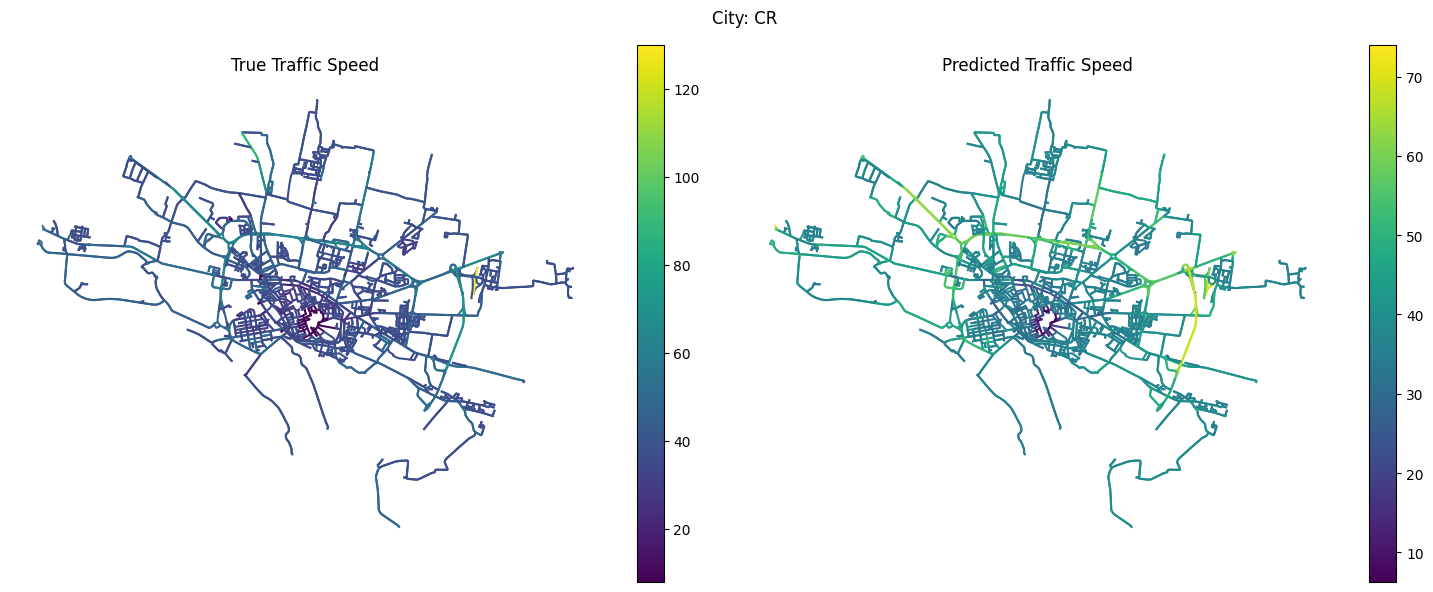

In [23]:
plot_predictions('CR', model, processed_data, edges)

In [24]:
#evaluate on VR and FE
vr_data = vr_data.to(device)
vr_test_loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {vr_test_loss:.4f}")
fe_data = fe_data.to(device)
fe_test_loss = test(model, fe_data, fe_data.test_mask)
print(f"Test Loss for FE: {fe_test_loss:.4f}")

Test Loss for VR: 136.4076
Test Loss for FE: 82.4858


Honestly I don't see any clear advantage of this model over the first one.

## Second model is like GPS:
It combines Performer and GNN at each layer.
Just like GPS I give the GNN the positional encoding.

In [29]:
class HybridModelv2(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_layers: int = 3,
        dropout: float = 0.4,
        combine_method: str = 'sum',  # 'sum', 'concat'
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # GPS layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # Transformer component
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                
                # GAT component
                'gat': GATConv(hidden_channels, hidden_channels // heads, 
                               heads=heads, concat=True, dropout=dropout),
                
                # Output normalizations for both branches
                'trans_norm': nn.LayerNorm(hidden_channels),
                'gat_norm': nn.LayerNorm(hidden_channels),
                
                # Combination method
                'combine': self._make_combiner(combine_method, hidden_channels),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def _make_combiner(self, method, hidden_channels):
        if method == 'sum':
            return nn.Identity()
        elif method == 'concat':
            return nn.Sequential(
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.ReLU()
            )
        
    
    def forward(self, x, pe, edge_index, batch=None):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through GPS layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            
            # Transformer component
            x_trans = x_norm.unsqueeze(0)
            x_trans = layer['attention'](x_trans).squeeze(0)
            
            # GAT component
            x_gat = layer['gat'](x_norm, edge_index)
            
            # Normalize outputs from transformer and GAT
            x_trans = layer['trans_norm'](x_trans)
            x_gat = layer['gat_norm'](x_gat)
            
            # Combine the normalized outputs with residual connection
            if isinstance(layer['combine'], nn.Identity):  # Sum
                x_combined = x_trans + x_gat + x  # Residual
            elif isinstance(layer['combine'], nn.Sequential):  # Concat
                x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
            
            # Feed-forward network with residual
            x = x_combined + layer['ffn'](x_combined)
        
        # Edge prediction
        src, dst = edge_index
        edge_features = torch.cat([x[src], x[dst]], dim=1)
        edge_pred = self.output_layer(edge_features)
        
        return edge_pred
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.layers:
            layer['attention'].redraw_projection_matrix()

In [30]:
device = 'cpu' #GAT do not support mps yet
model = HybridModelv2(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

HybridModelv2(
  (node_emb): Linear(in_features=5, out_features=48, bias=True)
  (pe_lin): Linear(in_features=20, out_features=16, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
      (gat): GATConv(64, 16, heads=4)
      (trans_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (gat_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (combine): Identity()
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Dropout(p=0.4, inplace=False)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (output_layer): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropou

In [31]:
# Train and evaluate the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
def train(model, data):
    model.train()
    optimizer.zero_grad()
    if epoch < 5:
        redraw_freq = 1
    elif epoch < 150:
        redraw_freq = 30
    else:
        redraw_freq = 1111
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()

In [33]:
# Train loop
EPOCHS = 1000
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Reset epoch losses
    epoch_train_loss = 0
    epoch_val_loss = 0
    num_batches = 0
    
    # Process all batches in an epoch
    for batch in loader:
        batch = batch.to(device)
        train_loss = train(model, batch)
        val_loss = test(model, batch, batch.val_mask)
        
        # Accumulate batch losses
        epoch_train_loss += train_loss
        epoch_val_loss += val_loss
        num_batches += 1
    
    # Calculate average losses for the epoch
    epoch_train_loss /= num_batches
    epoch_val_loss /= num_batches
    
    # Record epoch losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Scheduler step with average validation loss
    scheduler.step(epoch_val_loss)
    
    # Early stopping based on epoch validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_models/best_gpslike_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 10: Train Loss: 84.0677, Val Loss: 76.4046
Epoch 20: Train Loss: 83.1126, Val Loss: 79.3628
Epoch 30: Train Loss: 86.5323, Val Loss: 80.7923
Epoch 40: Train Loss: 81.5185, Val Loss: 77.8728
Epoch 50: Train Loss: 81.5129, Val Loss: 78.9646
Epoch 60: Train Loss: 83.5393, Val Loss: 78.0369
Epoch 70: Train Loss: 81.0082, Val Loss: 79.1046
Epoch 80: Train Loss: 80.8793, Val Loss: 80.7066
Epoch 90: Train Loss: 84.4169, Val Loss: 93.2596
Epoch 100: Train Loss: 80.0728, Val Loss: 81.3775
Epoch 110: Train Loss: 79.1955, Val Loss: 80.3591
Epoch 120: Train Loss: 86.1708, Val Loss: 76.7732
Epoch 130: Train Loss: 80.4685, Val Loss: 78.9821
Epoch 140: Train Loss: 80.6593, Val Loss: 80.9890
Epoch 150: Train Loss: 80.8590, Val Loss: 78.9737
Epoch 160: Train Loss: 79.7278, Val Loss: 79.8091
Epoch 170: Train Loss: 78.0716, Val Loss: 79.5925
Epoch 180: Train Loss: 78.1475, Val Loss: 78.3943
Epoch 190: Train Loss: 78.4209, Val Loss: 81.5051
Early stopping at epoch 192


In [34]:
# load the model
model = HybridModelv2(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
# Load the best model
model.load_state_dict(torch.load('best_models/best_gpslike_model.pth'))
model.to(device)

# Evaluate the model on the test set per city
test_losses = {}
for city, data in processed_data.items():
    data = data.to(device)
    test_loss = test(model, data, data.test_mask)
    test_losses[city] = test_loss
    print(f"Test Loss for {city}: {test_loss:.4f}")

Test Loss for PC: 95.3457
Test Loss for CR: 75.6446
Test Loss for PU: 63.2597
Test Loss for TR: 69.9860
Test Loss for RI: 55.1544


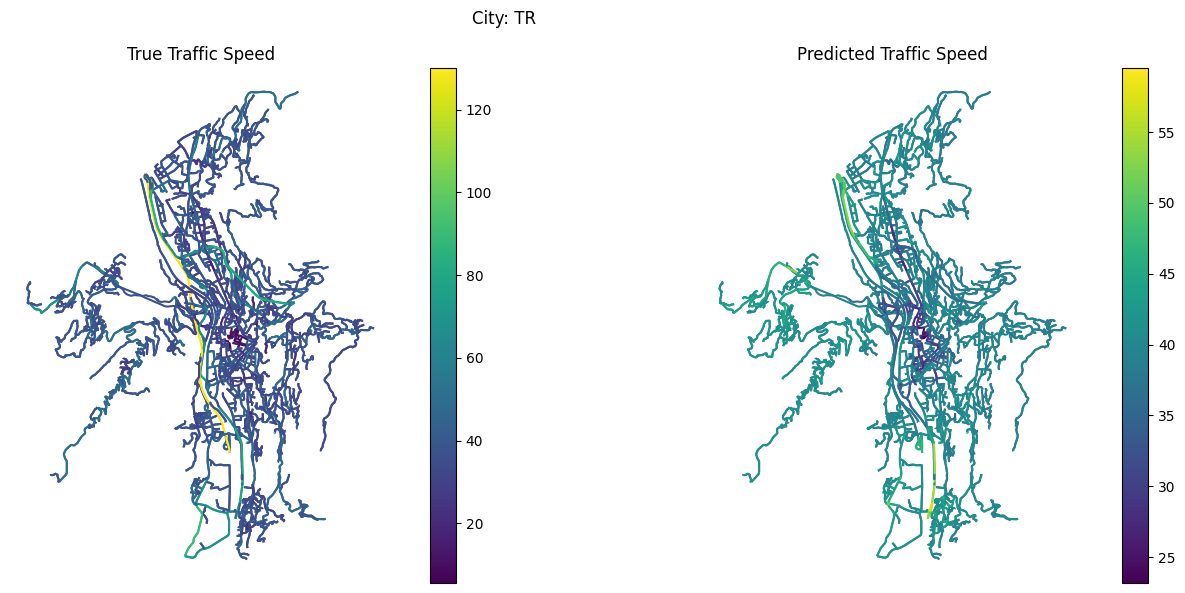

In [35]:
plot_predictions('TR', model, processed_data, edges)

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


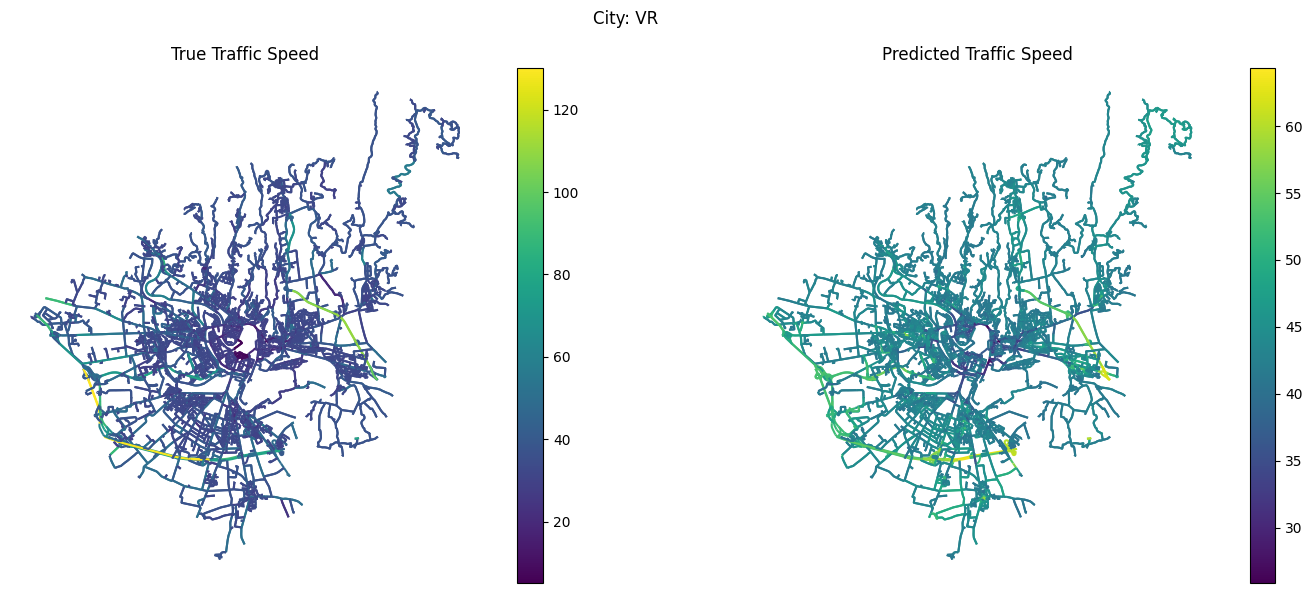

Test Loss for VR: 114.1755


In [36]:
#import a new city to test
nodes_vr = gpd.read_file(f'cities/nodes_VR.geojson')
edges_vr = gpd.read_file(f'cities/edges_VR.geojson')

nodes_vr = nodes_vr[[col for col in nodes_vr.columns if col in node_columns]]

vr_data = preprocess_data(nodes_vr, edges_vr)
plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

#compute loss
vr_data = vr_data.to(device)
vr_test_loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {vr_test_loss:.4f}")

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


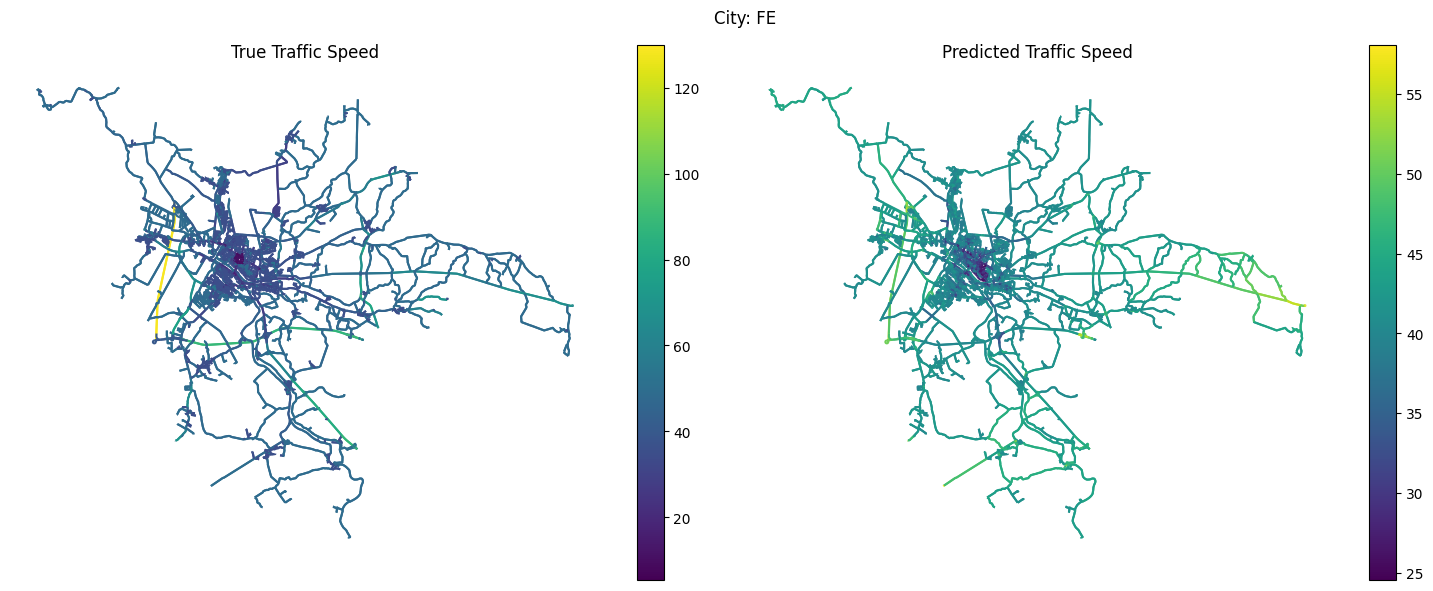

Test Loss for FE: 68.1888


In [37]:
#import a new city to test
nodes_fe = gpd.read_file(f'cities/nodes_FE.geojson')
edges_fe = gpd.read_file(f'cities/edges_FE.geojson')

nodes_fe = nodes_fe[[col for col in nodes_fe.columns if col in node_columns]]

fe_data = preprocess_data(nodes_fe, edges_fe)
plot_predictions('FE', model, {'FE': fe_data}, {'FE': edges_fe})

#compute loss
fe_data = fe_data.to(device)
fe_test_loss = test(model, fe_data, fe_data.test_mask)
print(f"Test Loss for FE: {fe_test_loss:.4f}")

Until now the three models do not have any clear advantage over the other.

## Third model is GPS:
It combines Performer and GNN at each layer.

In [52]:
from typing import Optional
from torch.nn import Linear, Sequential, ReLU, ModuleList, BatchNorm1d
from torch_geometric.nn import GINConv, GPSConv

class RedrawProjection:
    def __init__(self, model: torch.nn.Module,
                redraw_interval: Optional[int] = None):
        self.model = model
        self.redraw_interval = redraw_interval
        self.num_last_redraw = 0

    def redraw_projections(self):
        if not self.model.training or self.redraw_interval is None:
            return
        if self.num_last_redraw >= self.redraw_interval:
            fast_attentions = [
                module for module in self.model.modules()
                if isinstance(module, PerformerAttention)
            ]
            for fast_attention in fast_attentions:
                fast_attention.redraw_projection_matrix()
            self.num_last_redraw = 0
            return
        self.num_last_redraw += 1

class GPS(torch.nn.Module):
    def __init__(self, channels: int, pe_dim: int, num_layers: int,
                 attn_type: str = 'performer', dropout: float = 0.0):
        super().__init__()

        self.node_emb = Linear(data.x.shape[1], channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)

        self.convs = ModuleList()
        for _ in range(num_layers):
            nn = Sequential(
                Linear(channels, channels),
                ReLU(),
                Linear(channels, channels),
            )
            conv = GPSConv(channels, GINConv(nn), heads=4,
                           attn_type=attn_type, dropout=dropout)
            self.convs.append(conv)

        self.mlp = Sequential(
            Linear(2* channels, channels),
            ReLU(),
            Linear(channels, 1)
            
        )
        self.redraw_projection = RedrawProjection(
            self.convs,
            redraw_interval=30 if attn_type == 'performer' else None)

    def forward(self, x, pe, edge_index):
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        

        for conv in self.convs:
            x = conv(x, edge_index)
        
        # Edge-level prediction
        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)
        
        x = self.mlp(x)
        return x
    
device = 'cpu'

model = GPS(channels= 64, pe_dim=8, num_layers=2, attn_type= 'performer',
            dropout= 0.5).to(device)

In [53]:
# Train and evaluate the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30
def train(model, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()

In [54]:
# Train loop
EPOCHS = 1000
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Reset epoch losses
    epoch_train_loss = 0
    epoch_val_loss = 0
    num_batches = 0
    
    # Process all batches in an epoch
    for batch in loader:
        batch = batch.to(device)
        train_loss = train(model, batch)
        val_loss = test(model, batch, batch.val_mask)
        
        # Accumulate batch losses
        epoch_train_loss += train_loss
        epoch_val_loss += val_loss
        num_batches += 1
    
    # Calculate average losses for the epoch
    epoch_train_loss /= num_batches
    epoch_val_loss /= num_batches
    
    # Record epoch losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Scheduler step with average validation loss
    scheduler.step(epoch_val_loss)
    
    # Early stopping based on epoch validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_models/best_gps.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 10: Train Loss: 628.8611, Val Loss: 607.1943
Epoch 20: Train Loss: 92.3010, Val Loss: 106.0582
Epoch 30: Train Loss: 83.0502, Val Loss: 89.4099
Epoch 40: Train Loss: 74.6272, Val Loss: 83.1334
Epoch 50: Train Loss: 68.7554, Val Loss: 68.6906
Epoch 60: Train Loss: 64.9247, Val Loss: 69.0047
Epoch 70: Train Loss: 60.9700, Val Loss: 67.4449
Epoch 80: Train Loss: 59.5684, Val Loss: 73.1835
Epoch 90: Train Loss: 56.3984, Val Loss: 75.0075
Epoch 100: Train Loss: 54.2597, Val Loss: 70.3424
Epoch 110: Train Loss: 52.7284, Val Loss: 72.8559
Epoch 120: Train Loss: 50.9398, Val Loss: 73.2200
Epoch 130: Train Loss: 51.8205, Val Loss: 80.3097
Epoch 140: Train Loss: 49.4535, Val Loss: 65.6395
Epoch 150: Train Loss: 49.8853, Val Loss: 74.2506
Epoch 160: Train Loss: 49.7104, Val Loss: 74.7619
Epoch 170: Train Loss: 47.1988, Val Loss: 65.4332
Epoch 180: Train Loss: 47.1750, Val Loss: 60.4045
Epoch 190: Train Loss: 47.0031, Val Loss: 61.1785
Epoch 200: Train Loss: 47.1143, Val Loss: 62.9205
Epoch 

In [55]:
# load the model
model = GPS(channels= 64, pe_dim=8, num_layers=2, attn_type= 'performer',
            dropout= 0.5).to(device)
# Load the best model
model.load_state_dict(torch.load('best_models/best_gps.pth'))
model.to(device)


# Evaluate the model on the test set per city
test_losses = {}
for city, data in processed_data.items():
    data = data.to(device)
    test_loss = test(model, data, data.test_mask)
    test_losses[city] = test_loss
    print(f"Test Loss for {city}: {test_loss:.4f}")

Test Loss for PC: 75.5248
Test Loss for CR: 60.2953
Test Loss for PU: 70.6555
Test Loss for TR: 53.7990
Test Loss for RI: 37.8824


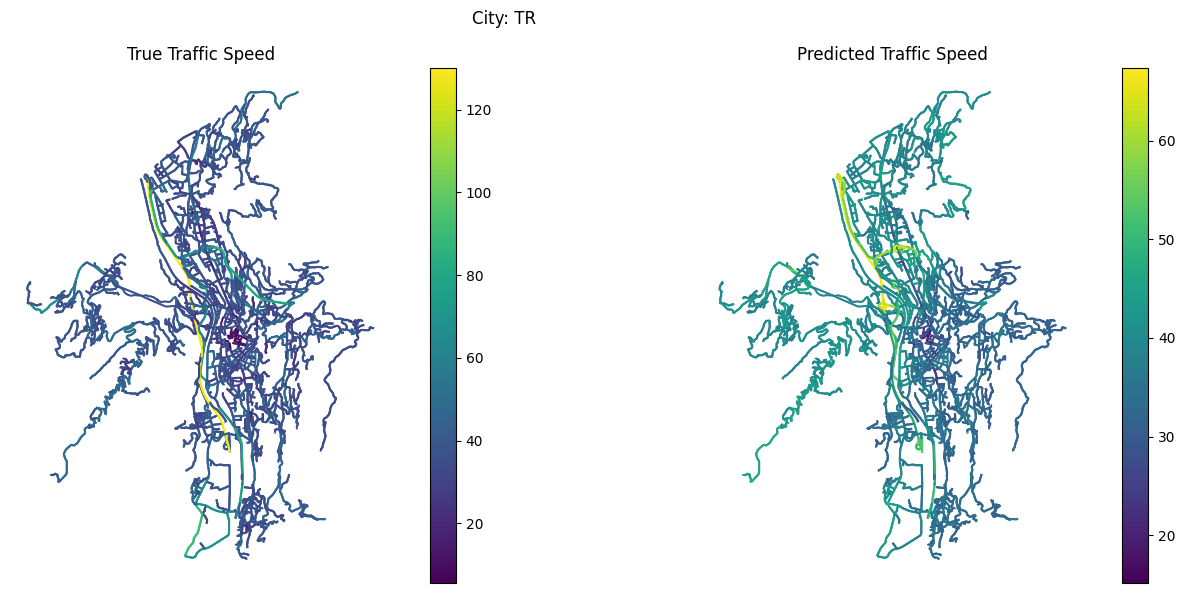

In [56]:
plot_predictions('TR', model, processed_data, edges)

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


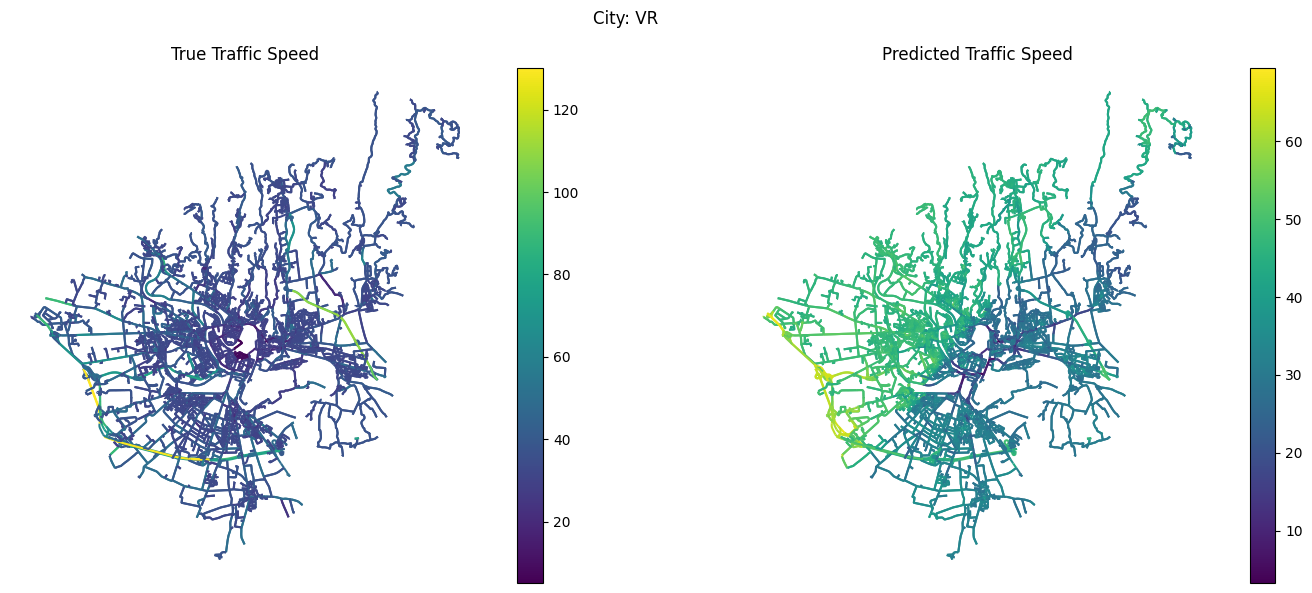

Test Loss for VR: 128.5780


In [57]:
#import a new city to test
nodes_vr = gpd.read_file(f'cities/nodes_VR.geojson')
edges_vr = gpd.read_file(f'cities/edges_VR.geojson')

nodes_vr = nodes_vr[[col for col in nodes_vr.columns if col in node_columns]]

vr_data = preprocess_data(nodes_vr, edges_vr)
plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

#compute loss
vr_data = vr_data.to(device)
vr_test_loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {vr_test_loss:.4f}")

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


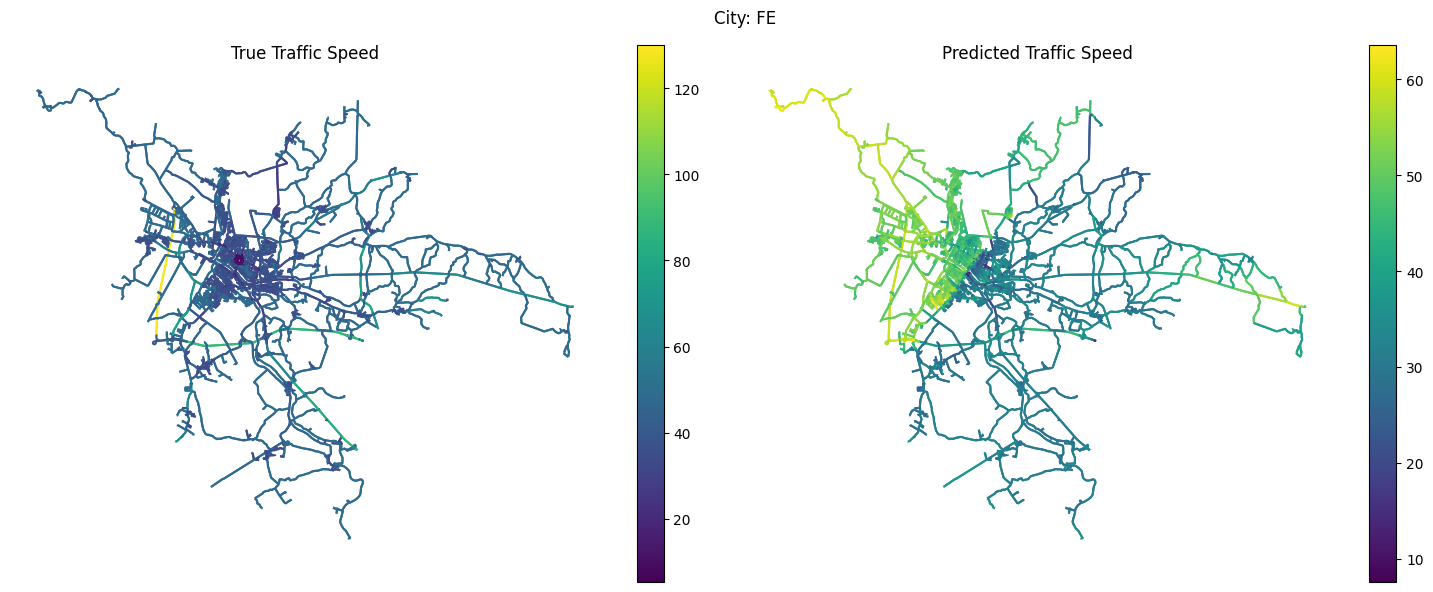

Test Loss for FE: 163.0040


In [58]:
#import a new city to test
nodes_fe = gpd.read_file(f'cities/nodes_FE.geojson')
edges_fe = gpd.read_file(f'cities/edges_FE.geojson')

nodes_fe = nodes_fe[[col for col in nodes_fe.columns if col in node_columns]]

fe_data = preprocess_data(nodes_fe, edges_fe)
plot_predictions('FE', model, {'FE': fe_data}, {'FE': edges_fe})

#compute loss
fe_data = fe_data.to(device)
fe_test_loss = test(model, fe_data, fe_data.test_mask)
print(f"Test Loss for FE: {fe_test_loss:.4f}")

# Fine-tuning part
We have multiple models saved, so no need to train them again.
We can try various types of fine-tuning.
## Fine-tuning with various percentage of nodes, uniformely distributed in space

In [38]:
from sklearn.neighbors import NearestNeighbors

def create_spatial_finetune_mask(node_data, edge_index, percentage=0.05, seed=0):
    """
    Create a fine-tuning mask using nearest neighbors to sample nodes uniformly in space.
    
    Args:
        node_data: DataFrame with node data containing 'x' and 'y' coordinates
        edge_index: PyTorch tensor with edge indices
        percentage: Percentage of nodes to sample for fine-tuning
        seed: Random seed for reproducibility
        
    Returns:
        edge_mask: Boolean mask for edges connected to sampled nodes
    """
    np.random.seed(seed)
    
    # Extract spatial coordinates
    x_coords = node_data['x'].values
    y_coords = node_data['y'].values
    coordinates = np.column_stack([x_coords, y_coords])
    
    # Determine spatial bounds
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    
    # Calculate number of points to sample
    num_nodes = len(node_data)
    num_points_to_sample = int(percentage * num_nodes)
    
    # Generate random points uniformly across the space
    random_points = np.column_stack([
        np.random.uniform(x_min, x_max, num_points_to_sample),
        np.random.uniform(y_min, y_max, num_points_to_sample)
    ])
    
    # Find nearest nodes to each random point
    nn = NearestNeighbors(n_neighbors=1).fit(coordinates)
    distances, indices = nn.kneighbors(random_points)
    
    # Get unique nearest nodes (may be fewer than random points if multiple points map to same node)
    selected_node_indices = np.unique(indices.flatten())
    
    # Create node mask
    node_mask = torch.zeros(num_nodes, dtype=torch.bool)
    node_mask[selected_node_indices] = True
    
    # Create edge mask - include edges that connect to selected nodes
    sources, targets = edge_index
    edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
    
    for i, (src, dst) in enumerate(zip(sources, targets)):
        if node_mask[src] or node_mask[dst]:
            edge_mask[i] = True
            
    return edge_mask

<Axes: >

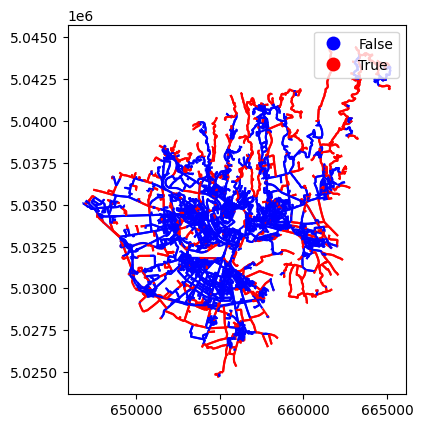

In [39]:
# VR finetune mask

vr_finetune_mask = create_spatial_finetune_mask(nodes_vr, vr_data.edge_index, percentage=0.15, seed=1)
#plot the mask
edges_vr['finetune_mask'] = vr_finetune_mask.cpu().numpy()
edges_vr.plot(column='finetune_mask', cmap='bwr', legend=True)

In [40]:
out = model(vr_data.x, vr_data.pe, vr_data.edge_index)
predictions = out.squeeze(-1)
print(predictions.shape)
print(predictions[vr_finetune_mask].shape)
print(vr_data.y[vr_finetune_mask].shape)

torch.Size([13798])
torch.Size([1563])
torch.Size([1563])


In [41]:
# load model for finetuning
model = HybridModelv2(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
# Load the best model
model.load_state_dict(torch.load('best_models/best_gpslike_model.pth'))
model.to(device)

loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {loss:.4f}")

Test Loss for VR: 114.1755


In [42]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def finetune(model, data, ft_mask):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass on full graph
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    
    # Loss only on masked edges
    loss = criterion(predictions[ft_mask], data.y[ft_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [43]:
# Fine-tuning loop
FINETUNE_EPOCHS = 50  # Reduced from 1000 in original training
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30  # Reduced from 100
ft_train_losses, ft_val_losses = [], []


for epoch in range(1, FINETUNE_EPOCHS + 1):
    # Training on fine-tuning mask
    ft_loss = finetune(model, vr_data, vr_finetune_mask)
    # Validation on original validation set
    val_loss = test(model, vr_data, vr_data.val_mask)
    
    # Scheduler and early stopping logic
    #scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_models/best_finetuned_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 5 == 0:  # Report more frequently
        print(f"FT Epoch {epoch}: Train Loss: {ft_loss:.4f}, Val Loss: {val_loss:.4f}")

FT Epoch 5: Train Loss: 126.4266, Val Loss: 127.5996
FT Epoch 10: Train Loss: 116.9368, Val Loss: 109.6016
FT Epoch 15: Train Loss: 113.6453, Val Loss: 84.9074
FT Epoch 20: Train Loss: 113.9984, Val Loss: 99.8874
FT Epoch 25: Train Loss: 115.7291, Val Loss: 90.9995
FT Epoch 30: Train Loss: 112.9476, Val Loss: 86.1873
FT Epoch 35: Train Loss: 97.3185, Val Loss: 88.5422
FT Epoch 40: Train Loss: 110.0830, Val Loss: 73.6121
FT Epoch 45: Train Loss: 106.1257, Val Loss: 93.4637
FT Epoch 50: Train Loss: 106.9064, Val Loss: 88.4903


Test Loss for VR after fine-tuning: 71.8031


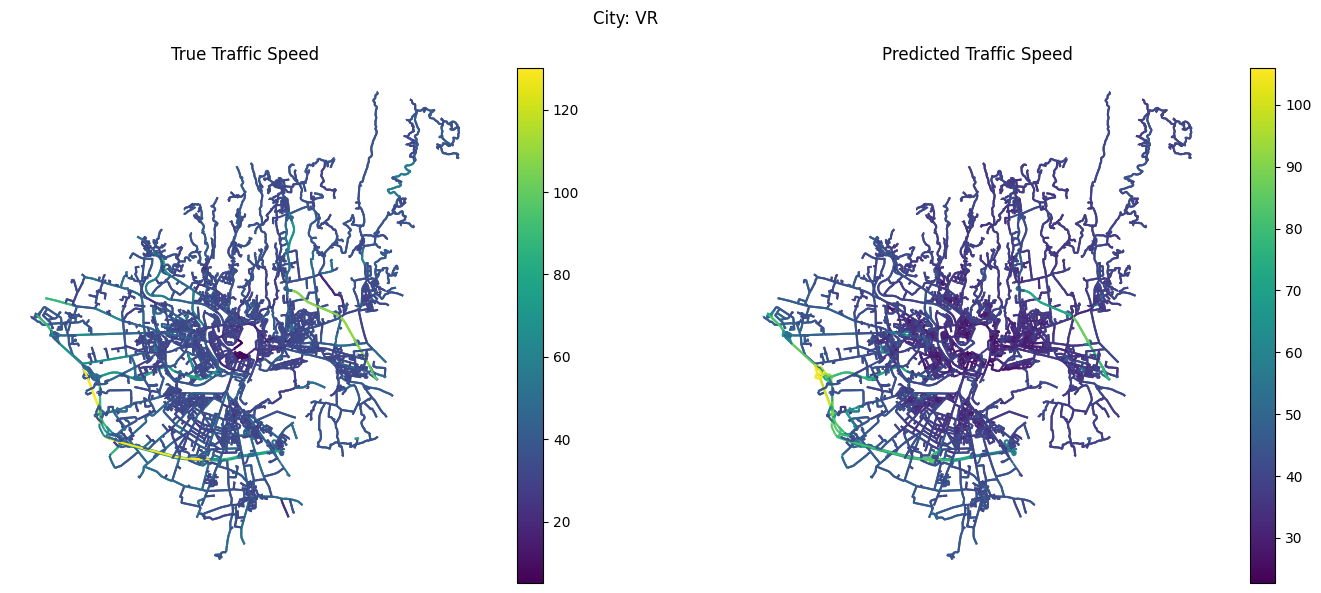

In [44]:
# Load the best fine-tuned model
model = HybridModelv2(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.load_state_dict(torch.load('best_models/best_finetuned_model.pth'))
model.to(device)

loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR after fine-tuning: {loss:.4f}")

plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

From my very small sample of tests, it seems that the gps like model is the one that learns the best.

## Fine-tuning with a spatial mask that shows only a portion of the city
I would expect this way of fine-tuning to be way worse since the model will not even see a single node of other regions.

In [45]:
def create_region_finetune_mask(node_data, edge_index, region_params=None):
    """
    Create a fine-tuning mask for nodes in a specific region of the city.
    
    Args:
        node_data: DataFrame with node data containing 'x' and 'y' coordinates
        edge_index: PyTorch tensor with edge indices
        region_params: Parameters for the region (quadrant): 'NE', 'NW', 'SE', 'SW'
        seed: Random seed for reproducibility
        
    Returns:
        edge_mask: Boolean mask for edges connected to nodes in the region
    """
    
    # Extract spatial coordinates
    x_coords = node_data['x'].values
    y_coords = node_data['y'].values
    
    # Determine spatial bounds of the entire city
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    
    if region_params is None:
        region_params = 'SW'  # Default to southwest quadrant
    
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    
    if region_params == 'NE':
        node_mask = (x_coords >= x_center) & (y_coords >= y_center)
    elif region_params == 'NW':
        node_mask = (x_coords <= x_center) & (y_coords >= y_center)
    elif region_params == 'SE':
        node_mask = (x_coords >= x_center) & (y_coords <= y_center)
    elif region_params == 'SW':
        node_mask = (x_coords <= x_center) & (y_coords <= y_center)
    elif region_params == 'N':
        node_mask = (y_coords >= y_center)
    elif region_params == 'S':
        node_mask = (y_coords <= y_center)
    elif region_params == 'E':
        node_mask = (x_coords >= x_center)
    elif region_params == 'W':
        node_mask = (x_coords <= x_center)
    elif region_params == 'C':
        radius = min(x_max - x_min, y_max - y_min) / 6
        node_mask = ((x_coords - x_center) ** 2 + (y_coords - y_center) ** 2) <= radius ** 2
    else:
        raise ValueError(f"Invalid quadrant: {region_params}")
    
    # Convert NumPy boolean array to PyTorch tensor
    node_mask = torch.tensor(node_mask, dtype=torch.bool)
    
    # Create edge mask - include edges that connect to selected nodes
    sources, targets = edge_index
    edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
    
    for i, (src, dst) in enumerate(zip(sources, targets)):
        if node_mask[src] or node_mask[dst]:
            edge_mask[i] = True
            
    return edge_mask

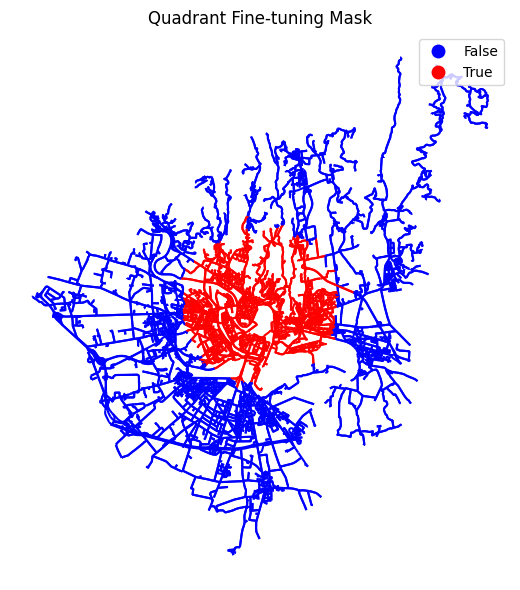

In [46]:
#check how the mask looks like
quadrant_mask = create_region_finetune_mask(nodes_vr, vr_data.edge_index, region_params='C')
# Visualize the masks
edges_vr['quadrant_mask'] = quadrant_mask.cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
edges_vr.plot(column='quadrant_mask', cmap='bwr', legend=True, ax=ax)
plt.title('Quadrant Fine-tuning Mask')
plt.axis('off')
plt.tight_layout()
plt.show()


Test Loss for VR: 136.4076


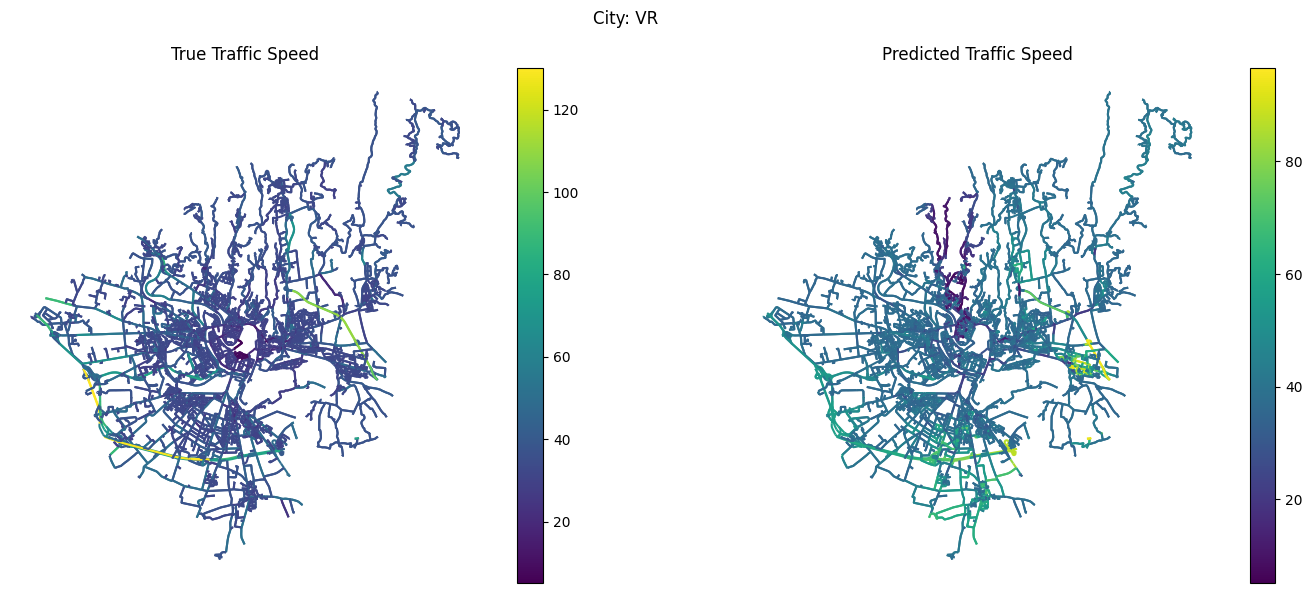

In [47]:
# Load the model for fine-tuning
model = HybridModel_variant(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
# Load the best model
model.load_state_dict(torch.load('best_models/best_model_var.pth'))
model.to(device)

loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {loss:.4f}")
plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

In [48]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def finetune(model, data, ft_mask):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass on full graph
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    
    # Loss only on masked edges
    loss = criterion(predictions[ft_mask], data.y[ft_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [49]:
vr_finetune_mask = create_region_finetune_mask(nodes_vr, vr_data.edge_index, region_params='C')
# Fine-tuning loop
FINETUNE_EPOCHS = 50  # Reduced from 1000 in original training
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30  # Reduced from 100
ft_train_losses, ft_val_losses = [], []


for epoch in range(1, FINETUNE_EPOCHS + 1):
    # Training on fine-tuning mask
    ft_loss = finetune(model, vr_data, vr_finetune_mask)
    # Validation on original validation set
    val_loss = test(model, vr_data, vr_data.val_mask)
    
    # Scheduler and early stopping logic
    #scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_models/best_region_finetuned_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 5 == 0:  # Report more frequently
        print(f"FT Epoch {epoch}: Train Loss: {ft_loss:.4f}, Val Loss: {val_loss:.4f}")

FT Epoch 5: Train Loss: 62.9043, Val Loss: 85.0732
FT Epoch 10: Train Loss: 62.8161, Val Loss: 84.4074
FT Epoch 15: Train Loss: 56.9571, Val Loss: 82.6010
FT Epoch 20: Train Loss: 59.1312, Val Loss: 83.4410
FT Epoch 25: Train Loss: 56.2758, Val Loss: 84.6125
FT Epoch 30: Train Loss: 53.7445, Val Loss: 87.1110
FT Epoch 35: Train Loss: 54.0835, Val Loss: 90.6318
FT Epoch 40: Train Loss: 52.6439, Val Loss: 92.9818
FT Epoch 45: Train Loss: 52.0920, Val Loss: 92.7892
Early stopping at epoch 47


Test Loss for VR after fine-tuning: 73.5396


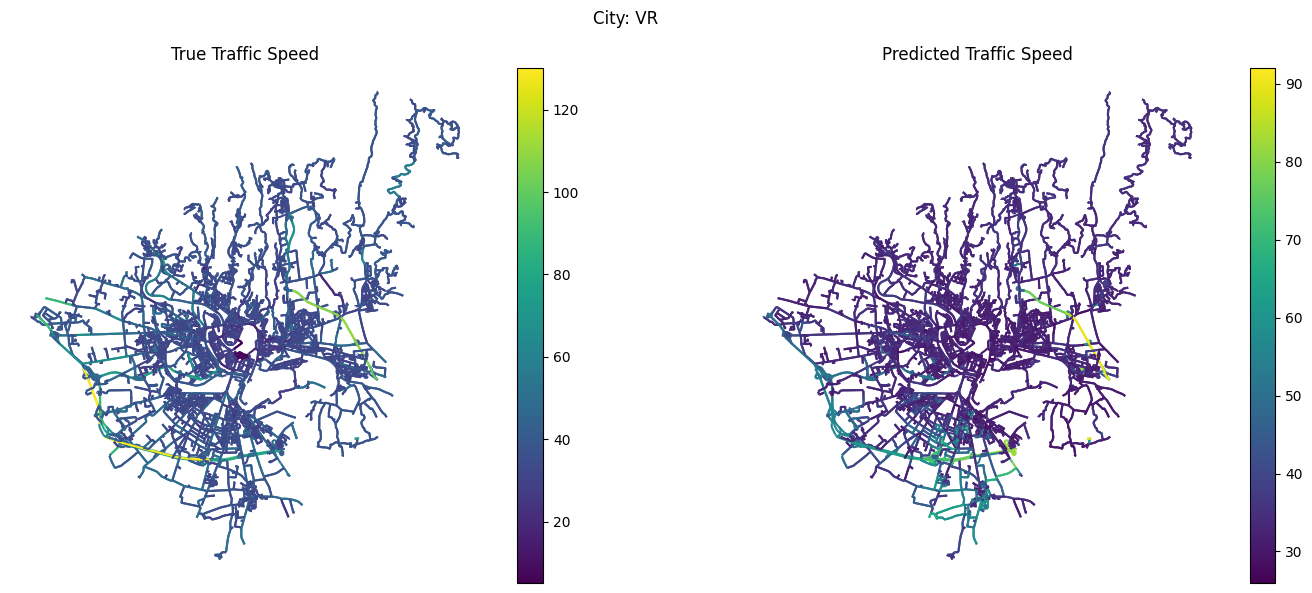

In [50]:
# Load the best fine-tuned model
model = HybridModel_variant(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.load_state_dict(torch.load('best_models/best_region_finetuned_model.pth'))
model.to(device)

loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR after fine-tuning: {loss:.4f}")

plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

# Let's try to automate the whole process
Training all the models and fine-tuning them with varying percentage of nodes and different regional masks.


In [51]:
# Load all the different models
device = 'cpu' 
def load_model(model_type, weights_path):    # function to load a model
    if model_type == "hybrid":
        model = HybridModel(
            in_channels=processed_data['TR'].num_features,
            pe_input_dim=processed_data['TR'].pe.shape[1],
            pe_dim=16,
            hidden_channels=64,
            heads=4,
            head_channels=16,
            num_transformer_layers=2,
            num_gat_layers=2,
            dropout=0.4,
            combine_method='sum'
        )
    elif model_type == "hybrid_variant":
        model = HybridModel_variant(
            in_channels=processed_data['TR'].num_features,
            pe_input_dim=processed_data['TR'].pe.shape[1],
            pe_dim=16,
            hidden_channels=64,
            heads=4,
            head_channels=16,
            num_transformer_layers=2,
            num_gat_layers=2,
            dropout=0.4,
            combine_method='sum'
        )
    elif model_type == "hybrid_v2":
        model = HybridModelv2(
            in_channels=processed_data['TR'].num_features,
            pe_input_dim=processed_data['TR'].pe.shape[1],
            pe_dim=16,
            hidden_channels=64,
            heads=4,
            head_channels=16,
            num_layers=2,
            dropout=0.4,
            combine_method='sum'
        )
    elif model_type == "gps":
        model = GPS(
            channels=64, 
            pe_dim=8, 
            num_layers=2, 
            attn_type='performer',
            dropout=0.5
        )
    
    model.load_state_dict(torch.load(weights_path))
    model.to(device)
    return model

# Load all models
models = {
    "hybrid": load_model("hybrid", 'best_models/best_model.pth'),
    "hybrid_variant": load_model("hybrid_variant", 'best_models/best_model_var.pth'),
    "hybrid_v2": load_model("hybrid_v2", 'best_models/best_gpslike_model.pth'),
    "gps": load_model("gps", 'best_models/best_gps.pth')
}

# Print loaded models
for name, model in models.items():
    print(f"Loaded {name} model")

NameError: name 'GPS' is not defined

In [57]:
# compute test loss for all models
test_losses = {}
for name, model in models.items():
    test_losses[name] = 0.0
    for batch in loader:
        batch = batch.to(device)
        test_loss = test(model, batch, batch.test_mask)
        test_losses[name] += test_loss
    test_losses[name] /= len(loader)
    print(f"Test Loss for {name}: {test_losses[name]:.4f}")

Test Loss for hybrid: 45.9400
Test Loss for hybrid_variant: 50.7883
Test Loss for hybrid_v2: 49.7188
Test Loss for gps: 72.6451


Baseline test loss for hybrid: 88.3570
Baseline test loss for hybrid_variant: 80.5080
Baseline test loss for hybrid_v2: 62.8008
Baseline test loss for gps: 200.5923

=== Fine-tuning hybrid model ===

Testing with 5.0% fine-tuning data
Mask includes 601 edges (4.36% of total)
Early stopping at epoch 38
Results for 5.0% fine-tuning:
  Test Loss: 66.6415
  Absolute Improvement: 21.7156
  Relative Improvement: 24.58%

Testing with 10.0% fine-tuning data
Mask includes 1120 edges (8.12% of total)
Results for 10.0% fine-tuning:
  Test Loss: 63.9393
  Absolute Improvement: 24.4177
  Relative Improvement: 27.64%

Testing with 15.0% fine-tuning data
Mask includes 1563 edges (11.33% of total)
Results for 15.0% fine-tuning:
  Test Loss: 53.7064
  Absolute Improvement: 34.6506
  Relative Improvement: 39.22%

Testing with 20.0% fine-tuning data
Mask includes 1936 edges (14.03% of total)
Results for 20.0% fine-tuning:
  Test Loss: 53.6087
  Absolute Improvement: 34.7483
  Relative Improvement: 39.33%

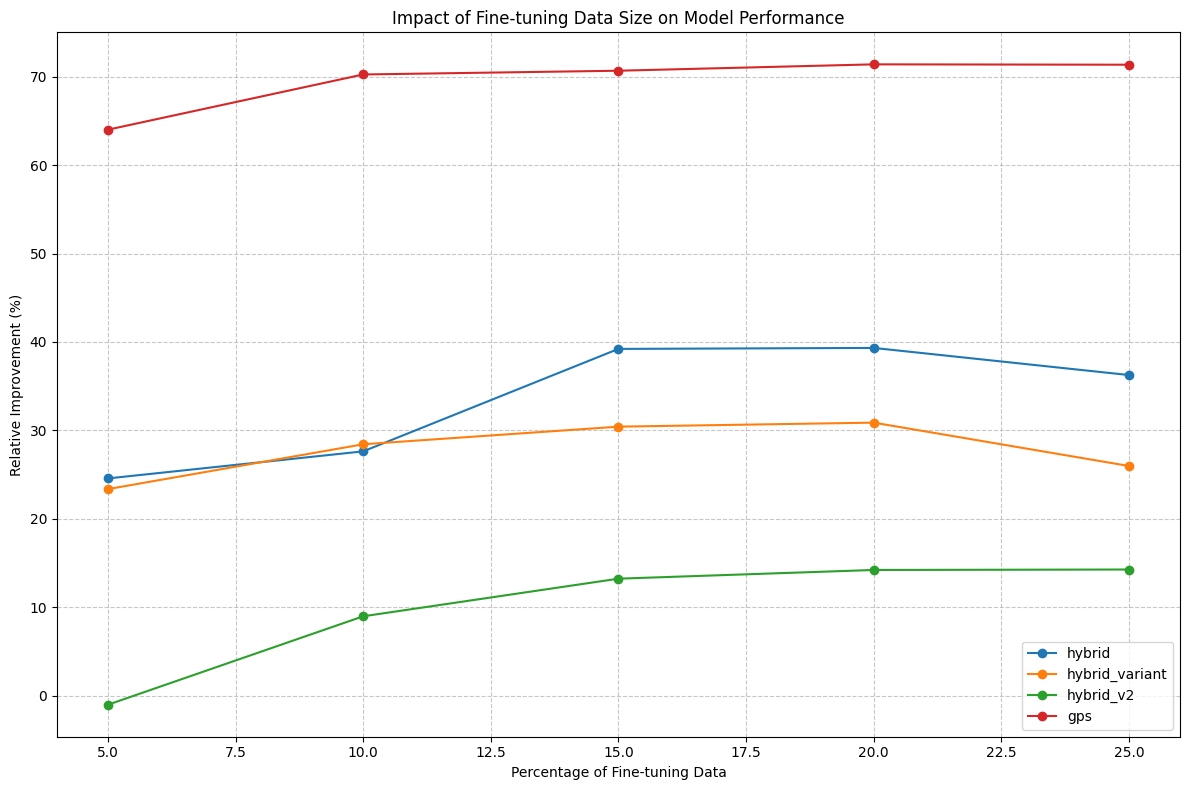

In [58]:
# Test each model with different fine-tuning percentages
percentages = [0.05, 0.10, 0.15, 0.20, 0.25]  # 5% to 25% of data
results = {}

# Ensure data is on the correct device
vr_data = vr_data.to(device)
criterion = nn.MSELoss()

# Get baseline performance for each model
for name, model in models.items():
    base_loss = test(model, vr_data, vr_data.test_mask)
    results[name] = {'base_loss': base_loss}
    print(f"Baseline test loss for {name}: {base_loss:.4f}")

# Fine-tune each model with different percentages
for name in models.keys():
    print(f"\n=== Fine-tuning {name} model ===")
    results[name]['percentage_results'] = {}
    
    for percentage in percentages:
        print(f"\nTesting with {percentage*100:.1f}% fine-tuning data")

        # Create a fresh copy of the model with original weights
        model_path = {
            "hybrid": "best_models/best_model.pth",
            "hybrid_variant": "best_models/best_model_var.pth", 
            "hybrid_v2": "best_models/best_gpslike_model.pth",
            "gps": "best_models/best_gps.pth"
        }
        model = load_model(name, model_path[name]) # needed to always start from the same weights
        model.to(device)
        
        
        # Create optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
        
        # Create fine-tuning mask
        ft_mask = create_spatial_finetune_mask(nodes_vr, vr_data.edge_index, percentage=percentage, seed=1)
        mask_size = ft_mask.sum().item()
        print(f"Mask includes {mask_size} edges ({mask_size/vr_data.num_edges*100:.2f}% of total)")
        
        # Fine-tuning loop
        EPOCHS = 50
        best_val_loss = float('inf')
        early_stop_counter = 0
        patience = 30
        
        for epoch in range(1, EPOCHS+1):
            # Training step
            model.train()
            optimizer.zero_grad()
            
            out = model(vr_data.x, vr_data.pe, vr_data.edge_index)
            pred = out.squeeze(-1)
            loss = criterion(pred[ft_mask], vr_data.y[ft_mask])
            loss.backward()
            optimizer.step()
            
            # Validation
            val_loss = test(model, vr_data, vr_data.val_mask)
            
            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), f'best_models/best_{name}_{percentage:.2f}.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
        
        # Load best model from this run
        model.load_state_dict(torch.load(f'best_models/best_{name}_{percentage:.2f}.pth'))
        
        # Test performance
        test_loss = test(model, vr_data, vr_data.test_mask)
        improvement = results[name]['base_loss'] - test_loss
        rel_improvement = improvement / results[name]['base_loss'] * 100
        
        results[name]['percentage_results'][percentage] = {
            'test_loss': test_loss,
            'absolute_improvement': improvement,
            'relative_improvement': rel_improvement
        }
        
        print(f"Results for {percentage*100:.1f}% fine-tuning:")
        print(f"  Test Loss: {test_loss:.4f}")
        print(f"  Absolute Improvement: {improvement:.4f}")
        print(f"  Relative Improvement: {rel_improvement:.2f}%")

# Print summary table
print("\n=== Summary of Fine-tuning Results ===")
for name in results:
    print(f"\nModel: {name}")
    print(f"Base test loss: {results[name]['base_loss']:.4f}")
    
    print("  Percentage | Test Loss | Abs Improvement | Rel Improvement")
    print("  -----------|-----------|-----------------|----------------")
    
    for percentage in percentages:
        res = results[name]['percentage_results'][percentage]
        print(f"  {percentage*100:9.1f}% | {res['test_loss']:9.4f} | {res['absolute_improvement']:15.4f} | {res['relative_improvement']:14.2f}%")

# Plot the results
plt.figure(figsize=(12, 8))

for name in results:
    x = [p*100 for p in percentages]  # Convert to percentages for x-axis
    y = [results[name]['percentage_results'][p]['relative_improvement'] for p in percentages]
    plt.plot(x, y, marker='o', label=name)

plt.xlabel('Percentage of Fine-tuning Data')
plt.ylabel('Relative Improvement (%)')
plt.title('Impact of Fine-tuning Data Size on Model Performance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Baseline test loss for hybrid: 88.3570
Baseline test loss for hybrid_variant: 80.5080
Baseline test loss for hybrid_v2: 62.8008
Baseline test loss for gps: 200.5923

=== Fine-tuning hybrid model ===

Testing with region: NE
Early stopping at epoch 41
Results for region NE:
  Test Loss: 63.6050
  Absolute Improvement: 24.7521
  Relative Improvement: 28.01%

Testing with region: NW
Early stopping at epoch 34
Results for region NW:
  Test Loss: 63.7542
  Absolute Improvement: 24.6029
  Relative Improvement: 27.84%

Testing with region: SE
Results for region SE:
  Test Loss: 59.8265
  Absolute Improvement: 28.5306
  Relative Improvement: 32.29%

Testing with region: SW
Early stopping at epoch 38
Results for region SW:
  Test Loss: 62.6052
  Absolute Improvement: 25.7519
  Relative Improvement: 29.15%

Testing with region: N
Results for region N:
  Test Loss: 62.5782
  Absolute Improvement: 25.7788
  Relative Improvement: 29.18%

Testing with region: S
Results for region S:
  Test Loss: 57.

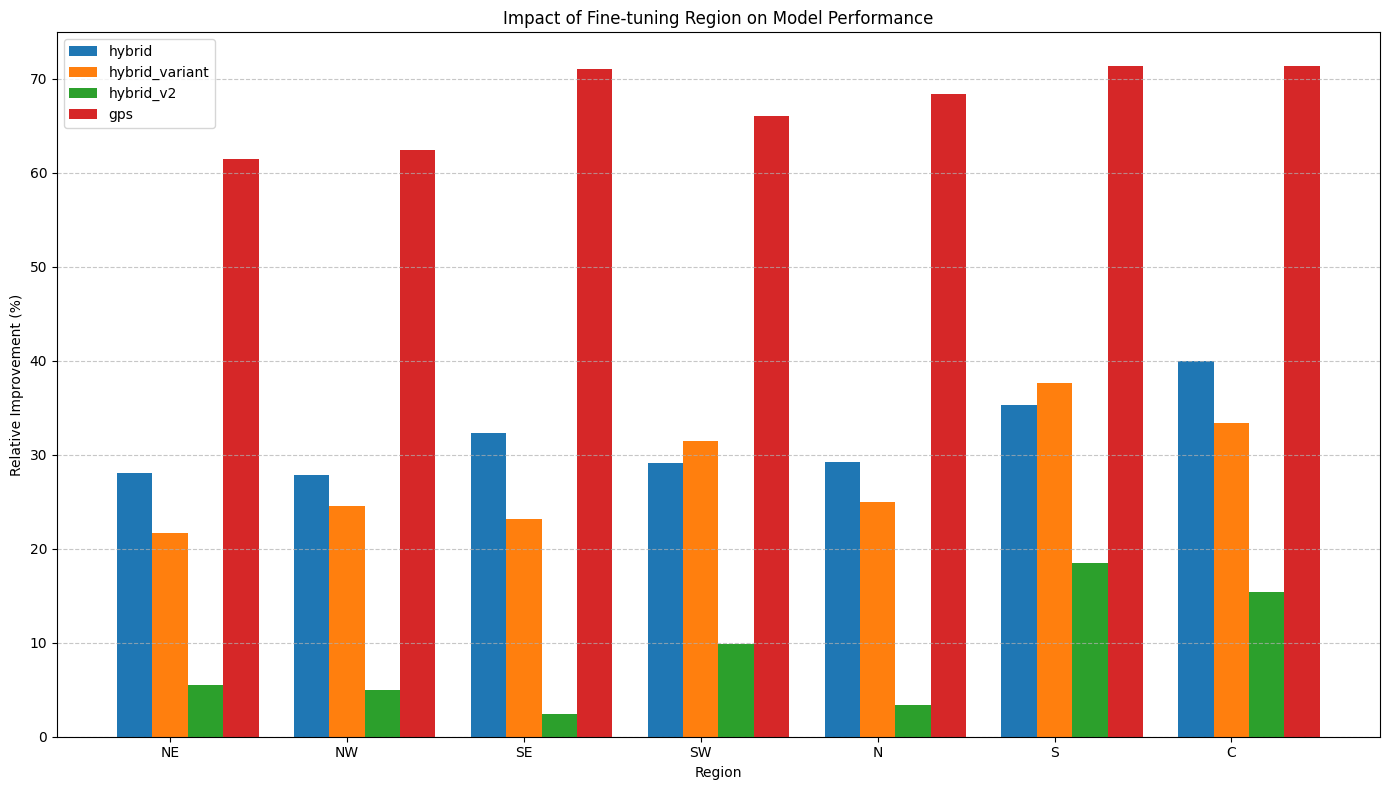

In [59]:
# Test each model with different regional fine-tuning
regions = ['NE', 'NW', 'SE', 'SW', 'N', 'S', 'C']  # Different regions of the city
results = {}

# Ensure data is on the correct device
vr_data = vr_data.to(device)
criterion = nn.MSELoss()

# Get baseline performance for each model
for name, model in models.items():
    base_loss = test(model, vr_data, vr_data.test_mask)
    results[name] = {'base_loss': base_loss}
    print(f"Baseline test loss for {name}: {base_loss:.4f}")

# Fine-tune each model with different regions
for name in models.keys():
    print(f"\n=== Fine-tuning {name} model ===")
    results[name]['region_results'] = {}
    
    for region in regions:
        print(f"\nTesting with region: {region}")

        # Create a fresh copy of the model with original weights
        model_path = {
            "hybrid": "best_models/best_model.pth",
            "hybrid_variant": "best_models/best_model_var.pth", 
            "hybrid_v2": "best_models/best_gpslike_model.pth",
            "gps": "best_models/best_gps.pth"
        }
        model = load_model(name, model_path[name]) # needed to always start from the same weights
        model.to(device)
        
        # Create optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
        
        # Create region-based fine-tuning mask
        ft_mask = create_region_finetune_mask(nodes_vr, vr_data.edge_index, region_params=region)

        # Fine-tuning loop
        EPOCHS = 50
        best_val_loss = float('inf')
        early_stop_counter = 0
        patience = 30
        
        for epoch in range(1, EPOCHS+1):
            # Training step
            model.train()
            optimizer.zero_grad()
            
            out = model(vr_data.x, vr_data.pe, vr_data.edge_index)
            pred = out.squeeze(-1)
            loss = criterion(pred[ft_mask], vr_data.y[ft_mask])
            loss.backward()
            optimizer.step()
            
            # Validation
            val_loss = test(model, vr_data, vr_data.val_mask)
            
            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), f'best_models/best_{name}_{region}.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
        
        # Load best model from this run
        model.load_state_dict(torch.load(f'best_models/best_{name}_{region}.pth'))
        
        # Test performance
        test_loss = test(model, vr_data, vr_data.test_mask)
        improvement = results[name]['base_loss'] - test_loss
        rel_improvement = improvement / results[name]['base_loss'] * 100
        
        results[name]['region_results'][region] = {
            'test_loss': test_loss,
            'absolute_improvement': improvement,
            'relative_improvement': rel_improvement
        }
        
        print(f"Results for region {region}:")
        print(f"  Test Loss: {test_loss:.4f}")
        print(f"  Absolute Improvement: {improvement:.4f}")
        print(f"  Relative Improvement: {rel_improvement:.2f}%")

# Print summary table
print("\n=== Summary of Regional Fine-tuning Results ===")
for name in results:
    print(f"\nModel: {name}")
    print(f"Base test loss: {results[name]['base_loss']:.4f}")
    
    print("  Region | Test Loss | Abs Improvement | Rel Improvement")
    print("  -------|-----------|-----------------|----------------")
    
    for region in regions:
        res = results[name]['region_results'][region]
        print(f"  {region:7s} | {res['test_loss']:9.4f} | {res['absolute_improvement']:15.4f} | {res['relative_improvement']:14.2f}%")

# Plot the results
plt.figure(figsize=(14, 8))

x = np.arange(len(regions))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

for name, result in results.items():
    y = [result['region_results'][region]['relative_improvement'] for region in regions]
    offset = width * multiplier
    rects = plt.bar(x + offset, y, width, label=name)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels
plt.xlabel('Region')
plt.ylabel('Relative Improvement (%)')
plt.title('Impact of Fine-tuning Region on Model Performance')
plt.xticks(x + width, regions)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Let's replicate with FE

Baseline test loss for hybrid: 70.7342
Baseline test loss for hybrid_variant: 66.8198
Baseline test loss for hybrid_v2: 85.7453
Baseline test loss for gps: 143.5949

=== Fine-tuning hybrid model ===

Testing with 5.0% fine-tuning data
Mask includes 658 edges (5.26% of total)
Early stopping at epoch 33
Results for 5.0% fine-tuning:
  Test Loss: 68.8740
  Absolute Improvement: 1.8602
  Relative Improvement: 2.63%

Testing with 10.0% fine-tuning data
Mask includes 1167 edges (9.33% of total)
Early stopping at epoch 36
Results for 10.0% fine-tuning:
  Test Loss: 63.2498
  Absolute Improvement: 7.4844
  Relative Improvement: 10.58%

Testing with 15.0% fine-tuning data
Mask includes 1564 edges (12.50% of total)
Results for 15.0% fine-tuning:
  Test Loss: 64.8799
  Absolute Improvement: 5.8543
  Relative Improvement: 8.28%

Testing with 20.0% fine-tuning data
Mask includes 1868 edges (14.93% of total)
Results for 20.0% fine-tuning:
  Test Loss: 61.2301
  Absolute Improvement: 9.5041
  Relativ

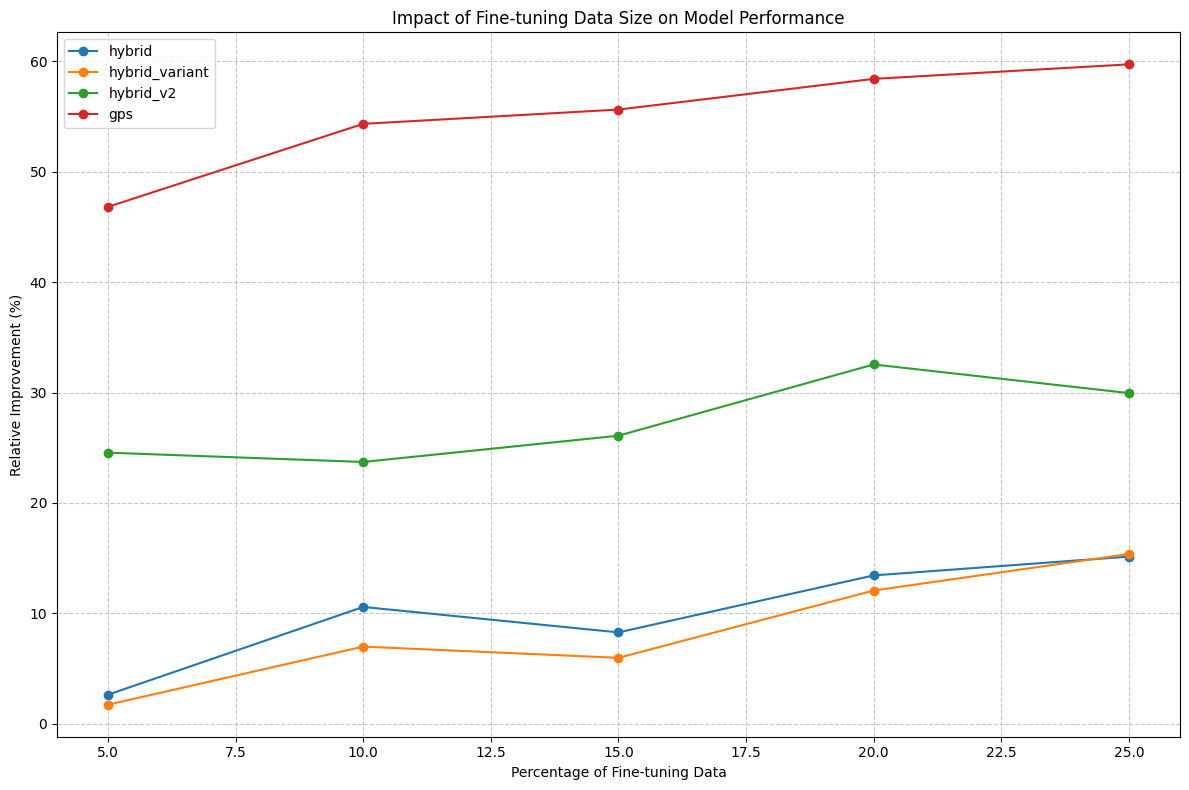

In [60]:
# Test each model with different fine-tuning percentages
percentages = [0.05, 0.10, 0.15, 0.20, 0.25]  # 5% to 25% of data
results = {}

# Ensure data is on the correct device
fe_data = fe_data.to(device)
criterion = nn.MSELoss()

# Get baseline performance for each model
for name, model in models.items():
    base_loss = test(model, fe_data, fe_data.test_mask)
    results[name] = {'base_loss': base_loss}
    print(f"Baseline test loss for {name}: {base_loss:.4f}")

# Fine-tune each model with different percentages
for name in models.keys():
    print(f"\n=== Fine-tuning {name} model ===")
    results[name]['percentage_results'] = {}
    
    for percentage in percentages:
        print(f"\nTesting with {percentage*100:.1f}% fine-tuning data")

        # Create a fresh copy of the model with original weights
        model_path = {
            "hybrid": "best_models/best_model.pth",
            "hybrid_variant": "best_models/best_model_var.pth", 
            "hybrid_v2": "best_models/best_gpslike_model.pth",
            "gps": "best_models/best_gps.pth"
        }
        model = load_model(name, model_path[name]) # needed to always start from the same weights
        model.to(device)
        
        
        # Create optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
        
        # Create fine-tuning mask
        ft_mask = create_spatial_finetune_mask(nodes_vr, fe_data.edge_index, percentage=percentage, seed=1)
        mask_size = ft_mask.sum().item()
        print(f"Mask includes {mask_size} edges ({mask_size/fe_data.num_edges*100:.2f}% of total)")
        
        # Fine-tuning loop
        EPOCHS = 50
        best_val_loss = float('inf')
        early_stop_counter = 0
        patience = 30
        
        for epoch in range(1, EPOCHS+1):
            # Training step
            model.train()
            optimizer.zero_grad()
            
            out = model(fe_data.x, fe_data.pe, fe_data.edge_index)
            pred = out.squeeze(-1)
            loss = criterion(pred[ft_mask], fe_data.y[ft_mask])
            loss.backward()
            optimizer.step()
            
            # Validation
            val_loss = test(model, fe_data, fe_data.val_mask)
            
            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), f'best_models/best_fe_{name}_{percentage:.2f}.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
        
        # Load best model from this run
        model.load_state_dict(torch.load(f'best_models/best_fe_{name}_{percentage:.2f}.pth'))
        
        # Test performance
        test_loss = test(model, fe_data, fe_data.test_mask)
        improvement = results[name]['base_loss'] - test_loss
        rel_improvement = improvement / results[name]['base_loss'] * 100
        
        results[name]['percentage_results'][percentage] = {
            'test_loss': test_loss,
            'absolute_improvement': improvement,
            'relative_improvement': rel_improvement
        }
        
        print(f"Results for {percentage*100:.1f}% fine-tuning:")
        print(f"  Test Loss: {test_loss:.4f}")
        print(f"  Absolute Improvement: {improvement:.4f}")
        print(f"  Relative Improvement: {rel_improvement:.2f}%")

# Print summary table
print("\n=== Summary of Fine-tuning Results ===")
for name in results:
    print(f"\nModel: {name}")
    print(f"Base test loss: {results[name]['base_loss']:.4f}")
    
    print("  Percentage | Test Loss | Abs Improvement | Rel Improvement")
    print("  -----------|-----------|-----------------|----------------")
    
    for percentage in percentages:
        res = results[name]['percentage_results'][percentage]
        print(f"  {percentage*100:9.1f}% | {res['test_loss']:9.4f} | {res['absolute_improvement']:15.4f} | {res['relative_improvement']:14.2f}%")

# Plot the results
plt.figure(figsize=(12, 8))

for name in results:
    x = [p*100 for p in percentages]  # Convert to percentages for x-axis
    y = [results[name]['percentage_results'][p]['relative_improvement'] for p in percentages]
    plt.plot(x, y, marker='o', label=name)

plt.xlabel('Percentage of Fine-tuning Data')
plt.ylabel('Relative Improvement (%)')
plt.title('Impact of Fine-tuning Data Size on Model Performance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Baseline test loss for hybrid: 70.7342
Baseline test loss for hybrid_variant: 66.8198
Baseline test loss for hybrid_v2: 85.7453
Baseline test loss for gps: 143.5949

=== Fine-tuning hybrid model ===

Testing with region: NE
Results for region NE:
  Test Loss: 63.1311
  Absolute Improvement: 7.6031
  Relative Improvement: 10.75%

Testing with region: NW
Results for region NW:
  Test Loss: 57.6345
  Absolute Improvement: 13.0996
  Relative Improvement: 18.52%

Testing with region: SE
Results for region SE:
  Test Loss: 56.6581
  Absolute Improvement: 14.0761
  Relative Improvement: 19.90%

Testing with region: SW
Results for region SW:
  Test Loss: 54.3951
  Absolute Improvement: 16.3391
  Relative Improvement: 23.10%

Testing with region: N
Results for region N:
  Test Loss: 57.8816
  Absolute Improvement: 12.8526
  Relative Improvement: 18.17%

Testing with region: S
Results for region S:
  Test Loss: 53.8898
  Absolute Improvement: 16.8444
  Relative Improvement: 23.81%

Testing with 

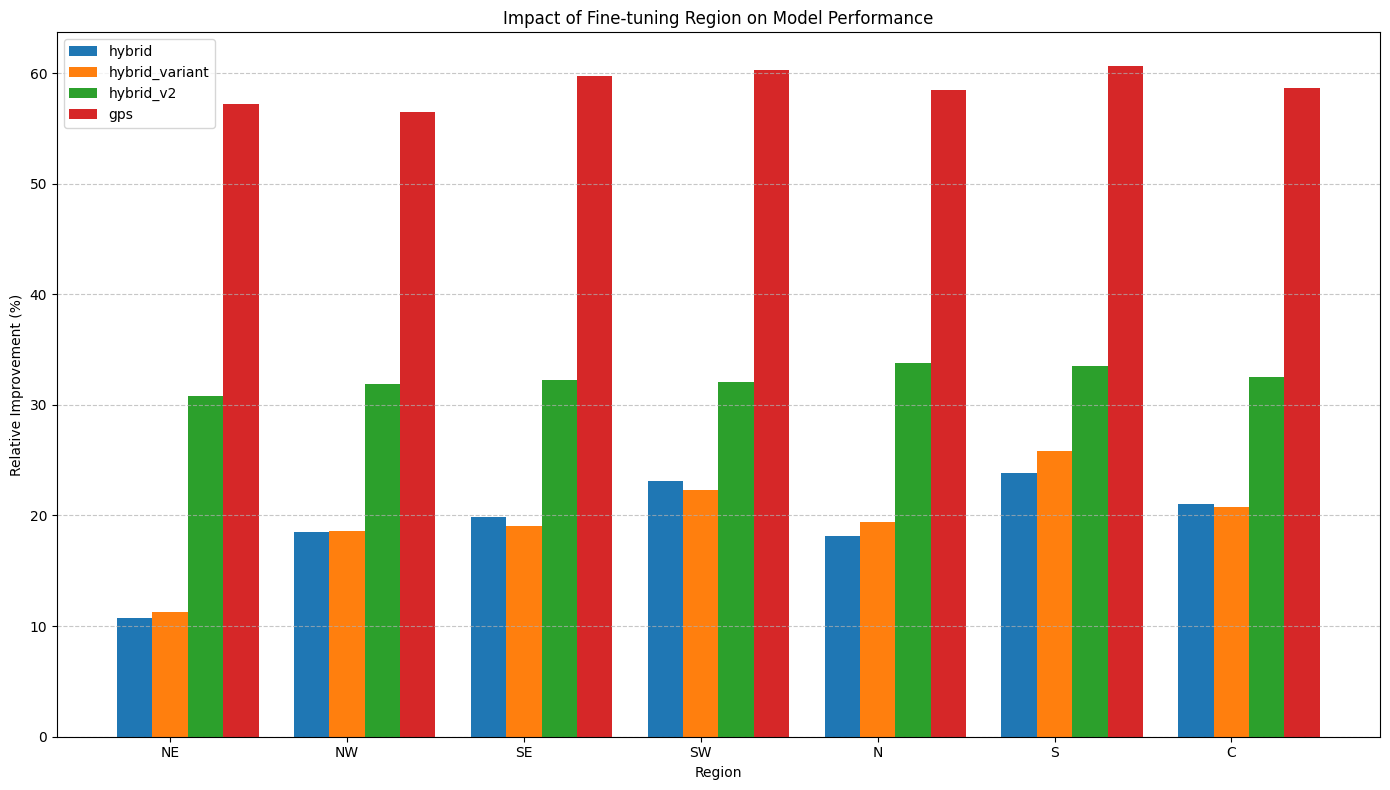

In [61]:
# Test each model with different regional fine-tuning
regions = ['NE', 'NW', 'SE', 'SW', 'N', 'S', 'C']  # Different regions of the city
results = {}

# Ensure data is on the correct device
fe_data = fe_data.to(device)
criterion = nn.MSELoss()

# Get baseline performance for each model
for name, model in models.items():
    base_loss = test(model, fe_data, fe_data.test_mask)
    results[name] = {'base_loss': base_loss}
    print(f"Baseline test loss for {name}: {base_loss:.4f}")

# Fine-tune each model with different regions
for name in models.keys():
    print(f"\n=== Fine-tuning {name} model ===")
    results[name]['region_results'] = {}
    
    for region in regions:
        print(f"\nTesting with region: {region}")

        # Create a fresh copy of the model with original weights
        model_path = {
            "hybrid": "best_models/best_model.pth",
            "hybrid_variant": "best_models/best_model_var.pth", 
            "hybrid_v2": "best_models/best_gpslike_model.pth",
            "gps": "best_models/best_gps.pth"
        }
        model = load_model(name, model_path[name]) # needed to always start from the same weights
        model.to(device)
        
        # Create optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
        
        # Create region-based fine-tuning mask
        ft_mask = create_region_finetune_mask(nodes_vr, fe_data.edge_index, region_params=region)

        # Fine-tuning loop
        EPOCHS = 50
        best_val_loss = float('inf')
        early_stop_counter = 0
        patience = 30
        
        for epoch in range(1, EPOCHS+1):
            # Training step
            model.train()
            optimizer.zero_grad()
            
            out = model(fe_data.x, fe_data.pe, fe_data.edge_index)
            pred = out.squeeze(-1)
            loss = criterion(pred[ft_mask], fe_data.y[ft_mask])
            loss.backward()
            optimizer.step()
            
            # Validation
            val_loss = test(model, fe_data, fe_data.val_mask)
            
            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), f'best_models/best_fe_{name}_{region}.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
        
        # Load best model from this run
        model.load_state_dict(torch.load(f'best_models/best_fe_{name}_{region}.pth'))
        
        # Test performance
        test_loss = test(model, fe_data, fe_data.test_mask)
        improvement = results[name]['base_loss'] - test_loss
        rel_improvement = improvement / results[name]['base_loss'] * 100
        
        results[name]['region_results'][region] = {
            'test_loss': test_loss,
            'absolute_improvement': improvement,
            'relative_improvement': rel_improvement
        }
        
        print(f"Results for region {region}:")
        print(f"  Test Loss: {test_loss:.4f}")
        print(f"  Absolute Improvement: {improvement:.4f}")
        print(f"  Relative Improvement: {rel_improvement:.2f}%")

# Print summary table
print("\n=== Summary of Regional Fine-tuning Results ===")
for name in results:
    print(f"\nModel: {name}")
    print(f"Base test loss: {results[name]['base_loss']:.4f}")
    
    print("  Region | Test Loss | Abs Improvement | Rel Improvement")
    print("  -------|-----------|-----------------|----------------")
    
    for region in regions:
        res = results[name]['region_results'][region]
        print(f"  {region:7s} | {res['test_loss']:9.4f} | {res['absolute_improvement']:15.4f} | {res['relative_improvement']:14.2f}%")

# Plot the results
plt.figure(figsize=(14, 8))

x = np.arange(len(regions))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

for name, result in results.items():
    y = [result['region_results'][region]['relative_improvement'] for region in regions]
    offset = width * multiplier
    rects = plt.bar(x + offset, y, width, label=name)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels
plt.xlabel('Region')
plt.ylabel('Relative Improvement (%)')
plt.title('Impact of Fine-tuning Region on Model Performance')
plt.xticks(x + width, regions)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [66]:
data

Data(x=[6008, 5], edge_index=[2, 12464], y=[12464], pe=[6008, 20], train_mask=[12464], val_mask=[12464], test_mask=[12464])

## Training the same models but with a different number of layers

In [67]:
# create models with 1 - 2 - 3 -4 layers
def create_model(model_type, layers, in_channels, pe_input_dim, pe_dim, hidden_channels, heads, head_channels, dropout, combine_method):
    if model_type == "hybrid":
        return HybridModel(
            in_channels=in_channels,
            pe_input_dim=pe_input_dim,
            pe_dim=pe_dim,
            hidden_channels=hidden_channels,
            heads=heads,
            head_channels=head_channels,
            num_transformer_layers=layers,
            num_gat_layers=layers,
            dropout=dropout,
            combine_method=combine_method
        )
    elif model_type == "hybrid_variant":
        return HybridModel_variant(
            in_channels=in_channels,
            pe_input_dim=pe_input_dim,
            pe_dim=pe_dim,
            hidden_channels=hidden_channels,
            heads=heads,
            head_channels=head_channels,
            num_transformer_layers=layers,
            num_gat_layers=layers,
            dropout=dropout,
            combine_method=combine_method
        )
    elif model_type == "hybrid_v2":
        return HybridModelv2(
            in_channels=in_channels,
            pe_input_dim=pe_input_dim,
            pe_dim=pe_dim,
            hidden_channels=hidden_channels,
            heads=heads,
            head_channels=head_channels,
            num_layers=layers,
            dropout=dropout,
            combine_method=combine_method
        )
    elif model_type == "gps":
        return GPS(
            channels=hidden_channels, 
            pe_dim=pe_input_dim, 
            num_layers=layers, 
            attn_type='performer',
            dropout=dropout
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")
# Create models with different layers
layers_list = [1, 2, 3, 4]
model_types = ["hybrid", "hybrid_variant", "hybrid_v2", "gps"]
models = {}
for model_type in model_types:
    models[model_type] = {}
    for layers in layers_list:
        models[model_type][layers] = create_model(
            model_type=model_type,
            layers=layers,
            in_channels=processed_data['TR'].num_features,
            pe_input_dim=processed_data['TR'].pe.shape[1],
            pe_dim=16,
            hidden_channels=64,
            heads=4,
            head_channels=16,
            dropout=0.4,
            combine_method='sum'
        )
        models[model_type][layers].to(device)

        print(f"Created {model_type} model with {layers} layers")

Created hybrid model with 1 layers
Created hybrid model with 2 layers
Created hybrid model with 3 layers
Created hybrid model with 4 layers
Created hybrid_variant model with 1 layers
Created hybrid_variant model with 2 layers
Created hybrid_variant model with 3 layers
Created hybrid_variant model with 4 layers
Created hybrid_v2 model with 1 layers
Created hybrid_v2 model with 2 layers
Created hybrid_v2 model with 3 layers
Created hybrid_v2 model with 4 layers
Created gps model with 1 layers
Created gps model with 2 layers
Created gps model with 3 layers
Created gps model with 4 layers


In [ ]:
# Train and evaluate models with different layers on the original dataset from scratch
criterion = nn.MSELoss()

def train(model, data, model_type, epoch):
    model.train()
    optimizer.zero_grad()
    if epoch < 5:
        redraw_freq = 1
    elif epoch < 150:
        redraw_freq = 30
    else:
        redraw_freq = 1111
    
    # Handle different redrawing methods based on model type
    if epoch % redraw_freq == 0:
        if model_type == "gps": # for GPS model do nothing
            pass        
            
        elif hasattr(model, "redraw_projection_matrix"):
            model.redraw_projection_matrix()
    
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()
    
results = {}
for model_type in models.keys():
    results[model_type] = {}
    for layers in models[model_type].keys():
        print(f"\n=== Training {model_type} model with {layers} layers ===")
        model = models[model_type][layers]
        model.to(device)
        
        # Initialize results dictionary properly
        results[model_type][layers] = {}
        
        # Create optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)

        # Train loop
        EPOCHS = 1000
        best_val_loss = float('inf')
        early_stop_counter = 0
        early_stop_patience = 100
        train_losses, val_losses = [], []

        for epoch in range(1, EPOCHS + 1):
            # Reset epoch losses
            epoch_train_loss = 0
            epoch_val_loss = 0
            num_batches = 0
            
            # Process all batches in an epoch
            for batch in loader:
                batch = batch.to(device)
                train_loss = train(model, batch, model_type, epoch)
                val_loss = test(model, batch, batch.val_mask)

                epoch_train_loss += train_loss
                epoch_val_loss += val_loss
                num_batches += 1
            epoch_train_loss /= num_batches
            epoch_val_loss /= num_batches
            scheduler.step(epoch_val_loss)
            train_losses.append(epoch_train_loss)
            val_losses.append(epoch_val_loss)
            # Early stopping check
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                torch.save(model.state_dict(), f'best_models/best_{model_type}_{layers}.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
        
        # Load best model from this run
        model.load_state_dict(torch.load(f'best_models/best_{model_type}_{layers}.pth'))
        
        # Test performance on vr and fe data
        test_loss_vr = test(model, vr_data, vr_data.test_mask)
        test_loss_fe = test(model, fe_data, fe_data.test_mask)
        
        print(f"Best Validation Loss for {model_type} with {layers} layers: {best_val_loss:.4f}")
        print(f"Test Loss for {model_type} with {layers} layers on VR: {test_loss_vr:.4f}")
        print(f"Test Loss for {model_type} with {layers} layers on FE: {test_loss_fe:.4f}")

        # Store results
        results[model_type][layers]['best_val_loss'] = best_val_loss
        results[model_type][layers]['test_loss_vr'] = test_loss_vr
        results[model_type][layers]['test_loss_fe'] = test_loss_fe


=== Training hybrid model with 1 layers ===
Early stopping at epoch 247
Best Validation Loss for hybrid with 1 layers: 53.4008
Test Loss for hybrid with 1 layers on VR: 80.5344
Test Loss for hybrid with 1 layers on FE: 81.3833

=== Training hybrid model with 2 layers ===
Early stopping at epoch 547
Best Validation Loss for hybrid with 2 layers: 48.6065
Test Loss for hybrid with 2 layers on VR: 74.8669
Test Loss for hybrid with 2 layers on FE: 72.0229

=== Training hybrid model with 3 layers ===
Early stopping at epoch 513
Best Validation Loss for hybrid with 3 layers: 45.3609
Test Loss for hybrid with 3 layers on VR: 74.7942
Test Loss for hybrid with 3 layers on FE: 70.9248

=== Training hybrid model with 4 layers ===
Early stopping at epoch 836
Best Validation Loss for hybrid with 4 layers: 41.3755
Test Loss for hybrid with 4 layers on VR: 79.1706
Test Loss for hybrid with 4 layers on FE: 73.7955

=== Training hybrid_variant model with 1 layers ===
Early stopping at epoch 278
Best Va


=== Summary of Results ===

Model Type: hybrid
  Layers: 1 | Best Val Loss: 53.4008 | Test Loss VR: 80.5344 | Test Loss FE: 81.3833
  Layers: 2 | Best Val Loss: 48.6065 | Test Loss VR: 74.8669 | Test Loss FE: 72.0229
  Layers: 3 | Best Val Loss: 45.3609 | Test Loss VR: 74.7942 | Test Loss FE: 70.9248
  Layers: 4 | Best Val Loss: 41.3755 | Test Loss VR: 79.1706 | Test Loss FE: 73.7955

Model Type: hybrid_variant
  Layers: 1 | Best Val Loss: 53.2540 | Test Loss VR: 68.1416 | Test Loss FE: 77.0031
  Layers: 2 | Best Val Loss: 48.0994 | Test Loss VR: 64.2957 | Test Loss FE: 80.7438
  Layers: 3 | Best Val Loss: 42.5526 | Test Loss VR: 74.6991 | Test Loss FE: 69.8204
  Layers: 4 | Best Val Loss: 36.3516 | Test Loss VR: 72.8774 | Test Loss FE: 73.0715

Model Type: hybrid_v2
  Layers: 1 | Best Val Loss: 67.1274 | Test Loss VR: 62.7496 | Test Loss FE: 107.7050
  Layers: 2 | Best Val Loss: 51.9009 | Test Loss VR: 62.7987 | Test Loss FE: 83.5906
  Layers: 3 | Best Val Loss: 37.6277 | Test Loss V

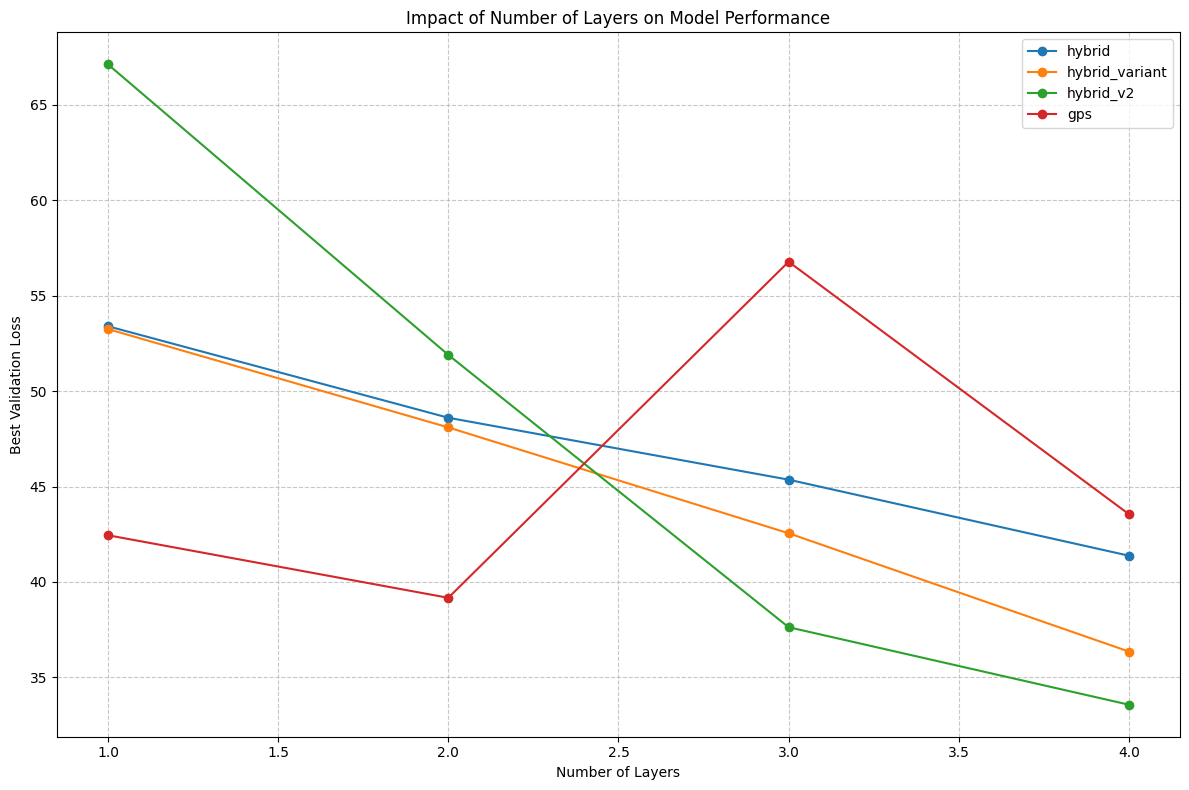

In [69]:
# show the results
print("\n=== Summary of Results ===")
for model_type in results.keys():
    print(f"\nModel Type: {model_type}")
    for layers in results[model_type].keys():
        res = results[model_type][layers]
        print(f"  Layers: {layers} | Best Val Loss: {res['best_val_loss']:.4f} | Test Loss VR: {res['test_loss_vr']:.4f} | Test Loss FE: {res['test_loss_fe']:.4f}")


# Plot the results
plt.figure(figsize=(12, 8))
for model_type in results.keys():
    x = [layers for layers in results[model_type].keys()]  # Number of layers
    y = [results[model_type][layers]['best_val_loss'] for layers in results[model_type].keys()]
    plt.plot(x, y, marker='o', label=model_type)
plt.xlabel('Number of Layers')
plt.ylabel('Best Validation Loss')
plt.title('Impact of Number of Layers on Model Performance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


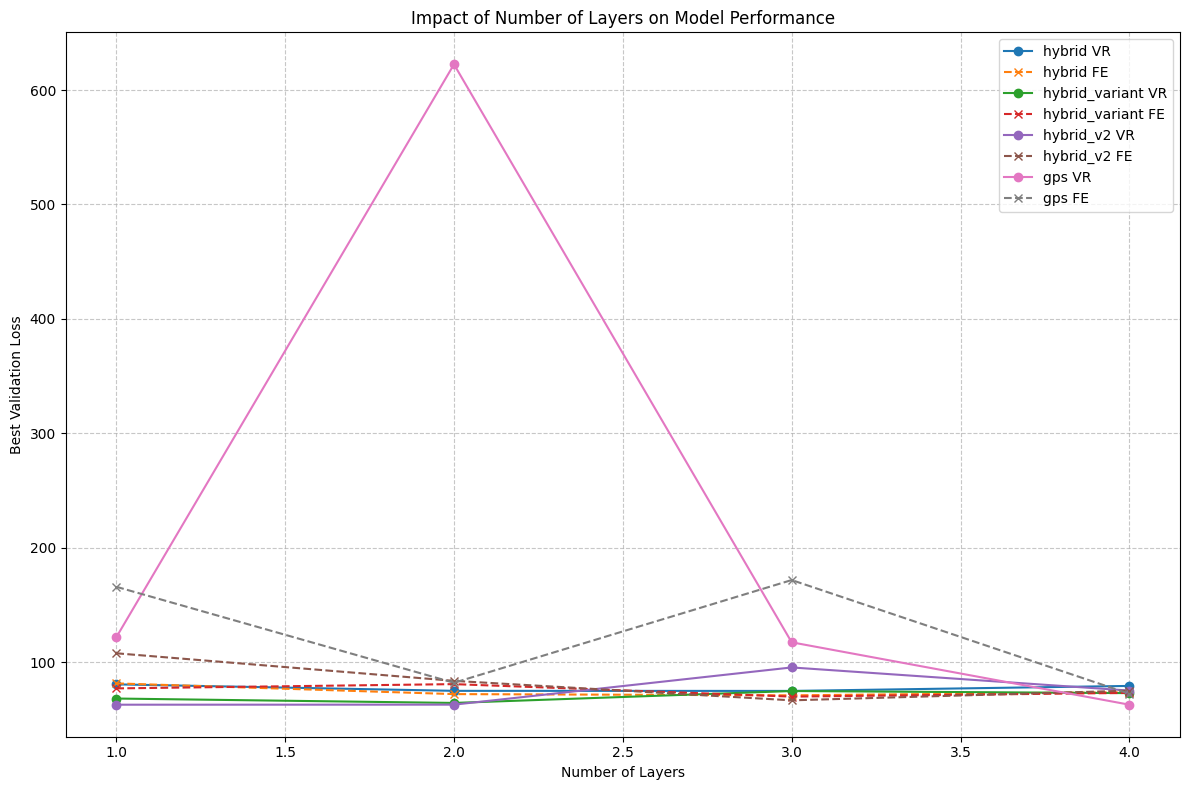

In [70]:
# Plot the results
plt.figure(figsize=(12, 8))
for model_type in results.keys():
    x = [layers for layers in results[model_type].keys()]  # Number of layers
    y_vr = [results[model_type][layers]['test_loss_vr'] for layers in results[model_type].keys()]
    y_fe = [results[model_type][layers]['test_loss_fe'] for layers in results[model_type].keys()]
    plt.plot(x, y_vr, marker='o', label=f"{model_type} VR")
    plt.plot(x, y_fe, marker='x', linestyle='--', label=f"{model_type} FE")
   
plt.xlabel('Number of Layers')
plt.ylabel('Best Validation Loss')
plt.title('Impact of Number of Layers on Model Performance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


In [84]:
#create predictions of the best model for all the data
model = HybridModel(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.load_state_dict(torch.load('best_models/best_hybrid_2.pth'))
model.to(device)
model.eval()
predictions = {}
for city in processed_data.keys():
    data = processed_data[city].to(device)
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        predictions[city] = out.squeeze(-1).cpu().numpy()
        print(f"Predictions for {city} computed.")




for city in processed_data.keys():
    edges[city]['predictions'] = predictions[city]

Predictions for PC computed.
Predictions for CR computed.
Predictions for PU computed.
Predictions for TR computed.
Predictions for RI computed.


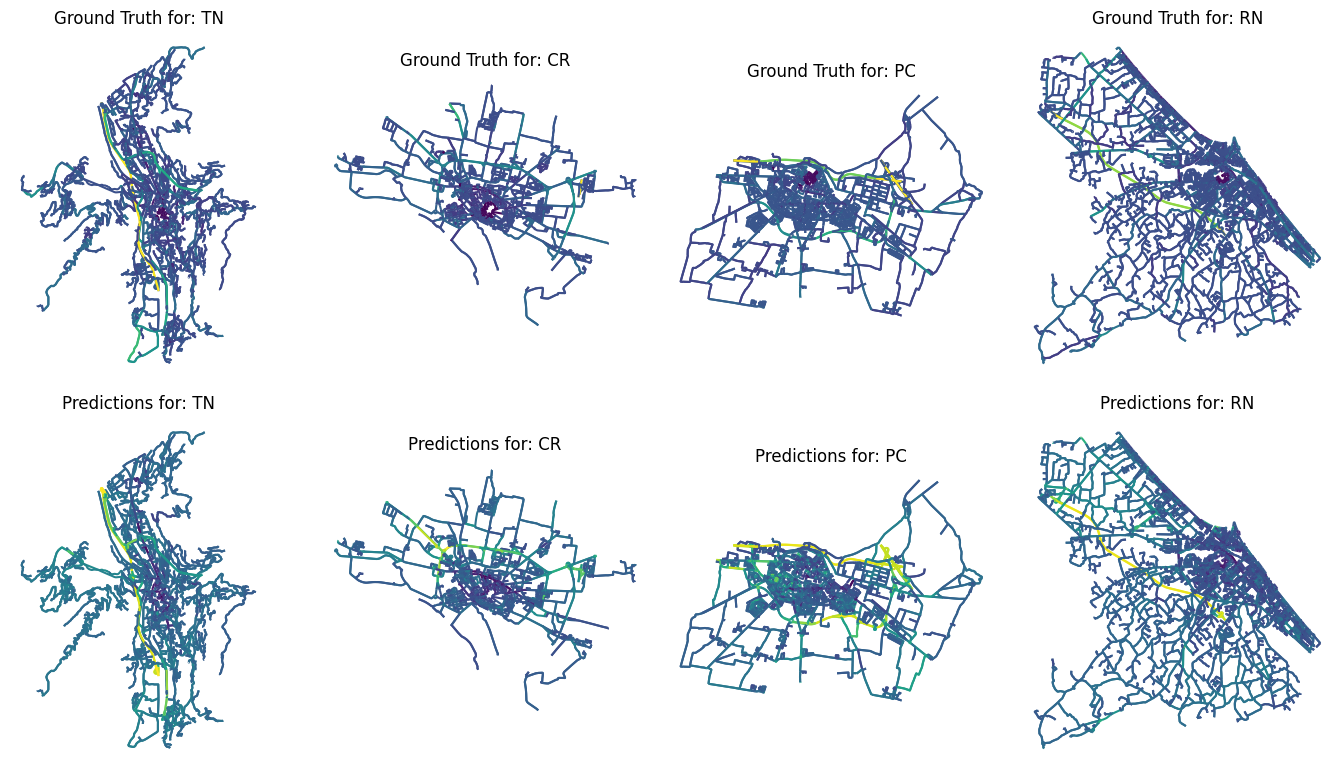

In [94]:
# plot all the cities of the dataset on a row and all the predictions on a second row
cities = ['TR', 'CR', 'PC','RI']
fig, axs = plt.subplots(2, len(cities), figsize=(14, 8))
for i, city in enumerate(cities):
    if city != 'TR' and city != 'RI':
        
        edges[city].plot(ax =axs[0, i], column = 'traffic_speed', cmap = 'viridis', legend = False)
        axs[0, i ].set_title(f"Ground Truth for: {city}")
        axs[0, i].set_axis_off()
        edges[city].plot(ax =axs[1, i], column = 'predictions', cmap = 'viridis', legend = False)
        axs[1, i].set_title(f"Predictions for: {city}")
        axs[1, i].set_axis_off()
    elif city == 'TR':
        edges[city].plot(ax =axs[0, i], column = 'traffic_speed', cmap = 'viridis', legend = False)
        axs[0, i ].set_title(f"Ground Truth for: TN")
        axs[0, i].set_axis_off()
        edges[city].plot(ax =axs[1, i], column = 'predictions', cmap = 'viridis', legend = False)
        axs[1, i].set_title(f"Predictions for: TN")
        axs[1, i].set_axis_off()
    else:
        edges[city].plot(ax =axs[0, i], column = 'traffic_speed', cmap = 'viridis', legend = False)
        axs[0, i ].set_title(f"Ground Truth for: RN")
        axs[0, i].set_axis_off()
        edges[city].plot(ax =axs[1, i], column = 'predictions', cmap = 'viridis', legend = False)
        axs[1, i].set_title(f"Predictions for: RN")
        axs[1, i].set_axis_off()
plt.tight_layout()
plt.show()
    


